# How wrong is `pypi-to-conda-v1`? An empirical audit

[prefix-dev/parselmouth#82](https://github.com/prefix-dev/parselmouth/issues/82) reports that
the `pypi-to-conda-v1` mapping returns *vendored* packages as the mapping target: asking for
PyPI `tzdata` can answer `psycopg`, because `psycopg` ships a vendored copy of `tzdata`'s
`.dist-info` and parselmouth's ingest picks it up.

This notebook measures how often that happens, using one file: parselmouth's own
`relations-v1/conda-forge/relations.jsonl.gz` (88 MB, 1.79M rows) — the source-of-truth table
behind every published mapping. (An earlier version of this notebook also cross-checked
against this repo's PyPI wheel corpus, to see whether a claimed release actually exists on
PyPI. It added no signal that the relations table's own `direct_url` column and the
structural detector in §4 didn't already provide, so it was dropped — the analysis below is
reproducible from that one download alone, no local database required.)

The questions, in order:

1. **Do the conda and PyPI versions agree?** The issue's first suggestion. → §2
2. **When they differ, is it a cosmetic suffix (`.post0`) or something bigger?** → §2
3. **Of the ones that differ substantively, how many are genuine false positives?** → §4, §5

### Findings

**Version agreement (§2).** 94.16 % of the 1,792,379 relations have a byte-identical
conda/PyPI version; another 1.57 % agree once you normalise (PEP 440 spelling, `.postN`,
local versions, epochs, `_` separators). So **95.73 % agree**, and the **76,549 (4.27 %) that
disagree are mostly not suffix noise** — 52,487 name a different release tuple outright and
20,630 differ because the PyPI side is a `0.0.0` build placeholder.

**A detector with a clean signal (§4).** `direct_url` yields an independent label for 24,776
relations. Against it, "the versions disagree" catches every vendored relation
(recall 1.00) at precision 0.60. Adding one structural condition —
*and the same conda artifact has another relation whose version does agree* —
reaches **precision 1.00 at recall 1.00**, using no name heuristics at all.
That rule flags **14,395 of 1,792,379 relations (0.80 %)** as vendored.

**Impact on the published files (§5).** The 20,409 `pypi-to-conda-v1/conda-forge/*.json`
files are reproduced here exactly (verified against the live R2 objects on a 20-file sample),
so all 269,141 published entries can be audited offline:

| | entries | % | files |
| --- | --- | --- | --- |
| version agrees | 263,489 | 97.90 % | 20,027 |
| **hard error** — published conda name is a different project | **558** | **0.21 %** | **169** |
| soft error — name right, version key does not match the artifact | 5,094 | 1.89 % | 1,418 |

**1,584 of 20,409 files (7.8 %) contain at least one suspect entry, and 382 files (1.9 %)
are suspect in every single entry.** Of the 558 hard errors, only 7 had a correct alternative
candidate available — the other 551 have no right answer at all, which is direct support for
the issue's proposal #3 ("allow *no answer*"). Full conclusions in §6.

---
## 1. The relations table

`relations-v1/{channel}/relations.jsonl.gz` is parselmouth's source of truth; the per-package
`pypi-to-conda-v1/{channel}/{name}.json` files served from R2 are a *derived view* of it.
Auditing the table therefore audits everything downstream, and it is one 88 MB download
rather than 20,409 requests.

In [38]:
import gzip
import itertools
import json
import time
import urllib.request
from pathlib import Path

import polars as pl

# The kernel's cwd is the notebook's directory, so anchor everything on the repo root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())

CHANNEL = "conda-forge"
BASE = "https://conda-mapping.prefix.dev"
UA = {"User-Agent": "parselmouth-audit/1.0 (+reroll-data notebook)"}
DATA = ROOT / "data/parselmouth"
DATA.mkdir(parents=True, exist_ok=True)
PYPI_DB = ROOT / "data/v.db"  # this repo's corpus; see the Makefile
print("repo root:", ROOT)


def cached(url, name):
    """Download once. The table is regenerated hourly upstream, so pin a local copy."""
    dst = DATA / name
    if not dst.exists():
        req = urllib.request.Request(url, headers=UA)
        with urllib.request.urlopen(req, timeout=900) as r, dst.open("wb") as f:
            while chunk := r.read(1 << 20):
                f.write(chunk)
    return dst


meta = json.loads(cached(f"{BASE}/relations-v1/{CHANNEL}/metadata.json",
                         f"metadata-{CHANNEL}.json").read_text())
p = cached(f"{BASE}/relations-v1/{CHANNEL}/relations.jsonl.gz", f"relations-{CHANNEL}.jsonl.gz")
print(json.dumps(meta, indent=2))
print(f"\n{p.relative_to(ROOT)} ({p.stat().st_size / 1e6:.1f} MB)\n")

with gzip.open(p, "rt") as f:
    for line in itertools.islice(f, 2):
        print(json.dumps(json.loads(line), indent=2))

repo root: /Users/anil/code/reroll-data
{
  "format_version": "1.0",
  "channel": "conda-forge",
  "generated_at": "2026-08-05 12:39:41.976450+00:00",
  "total_relations": 1792379,
  "unique_conda_packages": 1758073,
  "unique_pypi_packages": 20409,
  "description": "Conda to PyPI package relations table"
}

data/parselmouth/relations-conda-forge.jsonl.gz (88.5 MB)

{
  "conda_name": "21cmfast",
  "conda_filename": "21cmfast-3.0.2-py38hd394728_0.tar.bz2",
  "conda_hash": "a4b60e5d5f8dd122bacc3795cccffacf1f6aa3b17f1cada2f9b8e8e7e8d7ecf1",
  "pypi_name": "21cmfast",
  "pypi_version": "3.0.2",
  "channel": "conda-forge",
  "direct_url": null
}
{
  "conda_name": "21cmfast",
  "conda_filename": "21cmfast-3.0.2-py37h2887eb6_1.tar.bz2",
  "conda_hash": "633cd9a1d44523dd52479772dd63ad880626cd10c2308be4f389743045676ae4",
  "pypi_name": "21cmfast",
  "pypi_version": "3.0.2",
  "channel": "conda-forge",
  "direct_url": null
}


Two things about the schema matter for what follows.

`direct_url` is either absent or a list of strings, so polars' type inference fails on it
(the first 1.6M rows are all null) — the schema has to be given explicitly.

More importantly, **there is no `conda_version` column.** The README's description of the
table shows one, but what is actually published carries `conda_filename` instead, so the
conda version has to be recovered from the filename.

In [39]:
SCHEMA = {
    "conda_name": pl.String,
    "conda_filename": pl.String,
    "conda_hash": pl.String,
    "pypi_name": pl.String,
    "pypi_version": pl.String,
    "channel": pl.String,
    "direct_url": pl.List(pl.String),
}
t = time.time()
with gzip.open(p, "rb") as f:
    rel = pl.read_ndjson(f.read(), schema=SCHEMA)
print(f"{time.time() - t:.1f}s", rel.shape)
rel.null_count()

0.7s (1792379, 7)


conda_name,conda_filename,conda_hash,pypi_name,pypi_version,channel,direct_url
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,1671006


In [40]:
# A conda filename is {name}-{version}-{build}.{conda,tar.bz2}. Neither version nor
# build may contain "-", so the last two "-"-separated fields are always version and
# build, however many hyphens the name has.
#
# Note: a handful of rows carry a conda_name that does not match conda_filename
# (parselmouth#83, filed separately); harmless here since the version is always
# taken from the filename, not from conda_name.
stem = pl.col("conda_filename").str.replace(r"\.(conda|tar\.bz2)$", "")
parts = stem.str.split("-")
rel2 = rel.with_columns(
    conda_version=parts.list.get(-2, null_on_oob=True),
    conda_build=parts.list.get(-1, null_on_oob=True),
).drop("conda_build")
assert rel2.select(pl.col("conda_version").is_null().any()).item() is False

### The motivating case, in the raw table

`psycopg` vendors `tzdata`, so each `psycopg` artifact produces two relations. Note that the
vendored one carries `tzdata`'s version (`2021.5`) while the artifact's own version is `3.0.10`
— the version disagreement the issue proposes to key on is visible right here.

In [41]:
tz = rel2.filter(pl.col("pypi_name") == "tzdata")["conda_hash"].implode()
print(
    rel2.filter(pl.col("conda_hash").is_in(tz) & (pl.col("conda_name") == "psycopg"))
    .select("conda_filename", "conda_version", "pypi_name", "pypi_version")
    .sort("conda_filename")
    .head(6)
)

# Which conda packages does the table think provide PyPI tzdata at all?
print(
    rel2.filter(pl.col("pypi_name") == "tzdata")
    .group_by("conda_name")
    .agg(pl.len(), pl.col("pypi_version").unique().sort().str.join(", "))
    .sort("len", descending=True)
)

shape: (6, 4)
┌─────────────────────────────────┬───────────────┬───────────┬──────────────┐
│ conda_filename                  ┆ conda_version ┆ pypi_name ┆ pypi_version │
│ ---                             ┆ ---           ┆ ---       ┆ ---          │
│ str                             ┆ str           ┆ str       ┆ str          │
╞═════════════════════════════════╪═══════════════╪═══════════╪══════════════╡
│ psycopg-3.0.10-py310h5588dad_0… ┆ 3.0.10        ┆ psycopg   ┆ 3.0.10       │
│ psycopg-3.0.10-py310h5588dad_0… ┆ 3.0.10        ┆ tzdata    ┆ 2021.5       │
│ psycopg-3.0.10-py37h03978a9_0.… ┆ 3.0.10        ┆ psycopg   ┆ 3.0.10       │
│ psycopg-3.0.10-py37h03978a9_0.… ┆ 3.0.10        ┆ tzdata    ┆ 2021.5       │
│ psycopg-3.0.10-py38haa244fe_0.… ┆ 3.0.10        ┆ psycopg   ┆ 3.0.10       │
│ psycopg-3.0.10-py38haa244fe_0.… ┆ 3.0.10        ┆ tzdata    ┆ 2021.5       │
└─────────────────────────────────┴───────────────┴───────────┴──────────────┘
shape: (3, 3)
┌───────────────┬─────┬─

---
## 2. Do the conda and PyPI versions agree?

Issue #82's first suggestion. The naive form — string equality — is a lower bound, because
conda and PEP 440 disagree about spelling: conda versions may not contain `-` (so
`1.0.0-rc1` becomes `1.0.0_rc1`), and PEP 440 treats `1.0` and `1.0.0` as the same version.

So classify each distinct `(conda_version, pypi_version)` pair rather than call them
different. There are only 39,849 distinct pairs behind the 1.79M rows, so a pure-Python
classifier over `packaging.version` is cheap.

In [42]:
pairs = rel2.select("conda_version", "pypi_version").unique()
eq = rel2.filter(pl.col("conda_version") == pl.col("pypi_version")).height
print(f"relations                : {rel2.height:,}")
print(f"distinct conda artifacts : {rel2['conda_hash'].n_unique():,}")
print(f"distinct PyPI names      : {rel2['pypi_name'].n_unique():,}")
print(f"distinct conda names     : {rel2['conda_name'].n_unique():,}")
print(
    f"distinct version pairs   : {pairs.height:,}  ({pairs.filter(pl.col('conda_version') != pl.col('pypi_version')).height:,} differing)"
)
print(
    f"\nversions string-equal    : {eq:,} / {rel2.height:,} = {100 * eq / rel2.height:.2f}%"
)

relations                : 1,792,379
distinct conda artifacts : 1,758,073
distinct PyPI names      : 20,409
distinct conda names     : 20,542
distinct version pairs   : 39,849  (10,293 differing)

versions string-equal    : 1,687,759 / 1,792,379 = 94.16%


In [43]:
from functools import lru_cache
from packaging.version import InvalidVersion, Version


@lru_cache(maxsize=None)
def v(s):
    """PEP 440 parse, with a `_`->`-` retry for conda's hyphen ban (`1.2.3_1`)."""
    for cand in (s, s.replace("_", "-")):
        try:
            return Version(cand)
        except InvalidVersion:
            pass
    return None


AXES = ("epoch", "release", "pre", "post", "dev", "local")


def strip_zeros(release):
    r = list(release)
    while len(r) > 1 and r[-1] == 0:
        r.pop()
    return tuple(r)


def classify(c, p):
    """Name the *kind* of difference between a conda and a PyPI version string."""
    if c == p:
        return "exact"
    vc, vp = v(c), v(p)
    if vc is None or vp is None:
        return "unparseable"
    if vc == vp:
        return "pep440_equal"  # 1.0 vs 1.0.0, 1.0rc1 vs 1.0_rc1, ...
    kc = (vc.epoch, vc.release, vc.pre, vc.post, vc.dev, vc.local)
    kp = (vp.epoch, vp.release, vp.pre, vp.post, vp.dev, vp.local)
    diffs = [n for n, a, b in zip(AXES, kc, kp) if a != b]
    if diffs == ["post"]:
        return "post_only"  # 2.4.1 vs 2.4.1.post101
    if diffs == ["local"]:
        return "local_only"  # 3.3.0 vs 3.3.0+gitd9a1100d
    if diffs == ["dev"]:
        return "dev_only"
    if diffs == ["pre"]:
        return "pre_only"  # rc1 vs rc2 -- a different release
    if diffs == ["epoch"]:
        return "epoch_only"
    if "release" not in diffs:
        return "suffix_multi"  # several suffix axes at once, e.g. 0.14.1 vs 0.14.1a0+cb7b105
    rc, rp = strip_zeros(vc.release), strip_zeros(vp.release)
    if rc[: len(rp)] == rp or rp[: len(rc)] == rc:
        return "release_prefix"  # 6.25.7 vs 6.25.7.0.2, or 0.10.1 vs 0.0.0
    return "differ"  # genuinely different releases


pairs = pairs.with_columns(
    vclass=pl.struct("conda_version", "pypi_version").map_elements(
        lambda d: classify(d["conda_version"], d["pypi_version"]),
        return_dtype=pl.String,
    )
)
rel3 = rel2.join(pairs, on=["conda_version", "pypi_version"], how="left")

summary = (
    rel3["vclass"]
    .value_counts(sort=True)
    .with_columns(pct=(100 * pl.col("count") / rel3.height).round(3))
)
with pl.Config(tbl_rows=20):
    print(summary)

shape: (11, 3)
┌────────────────┬─────────┬────────┐
│ vclass         ┆ count   ┆ pct    │
│ ---            ┆ ---     ┆ ---    │
│ str            ┆ u32     ┆ f64    │
╞════════════════╪═════════╪════════╡
│ exact          ┆ 1687759 ┆ 94.163 │
│ differ         ┆ 52487   ┆ 2.928  │
│ release_prefix ┆ 20630   ┆ 1.151  │
│ pep440_equal   ┆ 16670   ┆ 0.93   │
│ post_only      ┆ 4012    ┆ 0.224  │
│ epoch_only     ┆ 3983    ┆ 0.222  │
│ unparseable    ┆ 1897    ┆ 0.106  │
│ local_only     ┆ 1732    ┆ 0.097  │
│ pre_only       ┆ 1535    ┆ 0.086  │
│ dev_only       ┆ 1023    ┆ 0.057  │
│ suffix_multi   ┆ 651     ┆ 0.036  │
└────────────────┴─────────┴────────┘


In [44]:
for k in [
    "pep440_equal",
    "post_only",
    "local_only",
    "epoch_only",
    "suffix_multi",
    "unparseable",
    "release_prefix",
    "pre_only",
    "differ",
]:
    ex = (
        rel3.filter(pl.col("vclass") == k)
        .select("conda_name", "conda_version", "pypi_name", "pypi_version")
        .unique()
        .sort("conda_name")
        .head(5)
    )
    print(f"=== {k}  ({rel3.filter(pl.col('vclass') == k).height:,} rows)")
    with pl.Config(
        tbl_hide_column_data_types=True,
        tbl_hide_dataframe_shape=True,
        tbl_width_chars=100,
    ):
        print(ex)

=== pep440_equal  (16,670 rows)
┌────────────┬──────────────────┬───────────┬─────────────────┐
│ conda_name ┆ conda_version    ┆ pypi_name ┆ pypi_version    │
╞════════════╪══════════════════╪═══════════╪═════════════════╡
│ acpype     ┆ 2020.07.25.08.41 ┆ acpype    ┆ 2020.7.25.8.41  │
│ acpype     ┆ 2020.03.15.13.27 ┆ acpype    ┆ 2020.3.15.13.27 │
│ acpype     ┆ 2019.10.05.12.26 ┆ acpype    ┆ 2019.10.5.12.26 │
│ alignn     ┆ 2024.12.02       ┆ alignn    ┆ 2024.12.2       │
│ apsw       ┆ 3.37.0.r1        ┆ apsw      ┆ 3.37.0.post1    │
└────────────┴──────────────────┴───────────┴─────────────────┘
=== post_only  (4,012 rows)
┌───────────────┬───────────────┬────────────────┬──────────────┐
│ conda_name    ┆ conda_version ┆ pypi_name      ┆ pypi_version │
╞═══════════════╪═══════════════╪════════════════╪══════════════╡
│ adios4dolfinx ┆ 0.9.1         ┆ adios4dolfinx  ┆ 0.9.1.post0  │
│ ai4s-jobq     ┆ 2.13.1        ┆ ai4s-jobq      ┆ 2.13.1.post2 │
│ airflow       ┆ 1.10.3post2   ┆ 

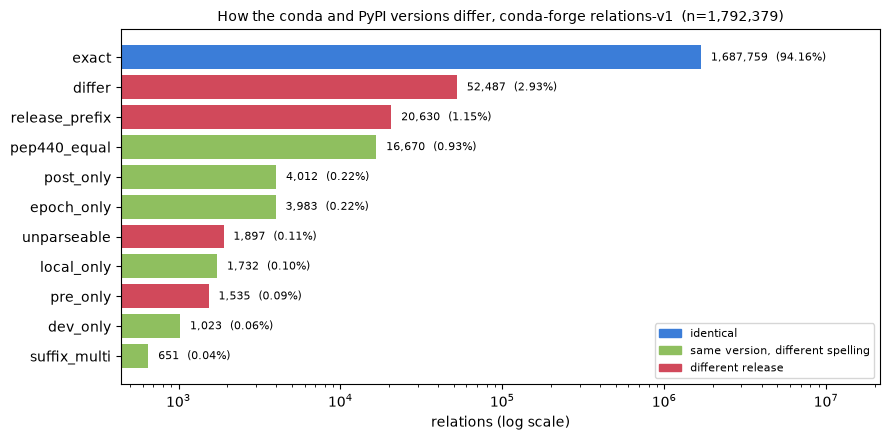

same version (identical or normalisation-equal): 1,715,830  95.73%
different release                              : 76,549  4.27%


In [45]:
import matplotlib.pyplot as plt

COSMETIC = [
    "pep440_equal",
    "post_only",
    "local_only",
    "dev_only",
    "epoch_only",
    "suffix_multi",
]
SUBSTANTIVE = ["release_prefix", "pre_only", "differ", "unparseable"]
COLOR = {
    **{k: "#3b7dd8" for k in ["exact"]},
    **{k: "#8fbf5f" for k in COSMETIC},
    **{k: "#d1495b" for k in SUBSTANTIVE},
}

s = summary.sort("count")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(s["vclass"], s["count"], color=[COLOR[k] for k in s["vclass"]])
ax.set_xscale("log")
for y, (k, n) in enumerate(zip(s["vclass"], s["count"])):
    ax.text(
        n * 1.15, y, f"{n:,}  ({100 * n / rel3.height:.2f}%)", va="center", fontsize=8
    )
ax.set_xlim(right=rel3.height * 12)
ax.set_xlabel("relations (log scale)")
ax.set_title(
    f"How the conda and PyPI versions differ, {CHANNEL} relations-v1  "
    f"(n={rel3.height:,})",
    fontsize=10,
)
handles = [
    plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#3b7dd8", "#8fbf5f", "#d1495b"]
]
ax.legend(
    handles,
    ["identical", "same version, different spelling", "different release"],
    fontsize=8,
    loc="lower right",
)
fig.tight_layout()
plt.show()

agree = rel3.filter(pl.col("vclass").is_in(["exact"] + COSMETIC)).height
print(
    f"same version (identical or normalisation-equal): {agree:,}  {100 * agree / rel3.height:.2f}%"
)
print(
    f"different release                              : {rel3.height - agree:,}  "
    f"{100 * (rel3.height - agree) / rel3.height:.2f}%"
)

**Answer to questions 1 and 2.** 94.16 % of relations agree exactly; **95.73 % agree once
spelling is normalised**, leaving **76,549 (4.27 %) that name a different release**.

The `.post0` hypothesis in the question is real but small, and almost always benign:
`post_only` (4,012), `epoch_only` (3,983 — conda-forge bumping an epoch to undo an upstream
version regression, all `dagster-*`), `local_only` (1,732 — conda-forge dropping a `+gitsha`
or `+cu118` local segment), `dev_only` (1,023) and `suffix_multi` (651). Together 0.64 % of
relations, and every sampled case is the same project. `pep440_equal` (16,670) is pure
spelling: `2020.03.15` vs `2020.3.15`, `3.23.1.r1` vs `3.23.1.post1`.

The buckets that matter are:

- **`differ` — 52,487 (2.93 %)**: a genuinely different release tuple. Contains both the
  vendoring in issue #82 *and* recipes whose metadata version simply drifts.
- **`release_prefix` — 20,630 (1.15 %)**: dominated by `0.0.0`, the placeholder a
  `setuptools-scm` build writes when the sdist has no git metadata. The conda name is right;
  the version is meaningless.
- **`pre_only` (1,535)** and **`unparseable` (1,897)**: nightly/dev builds where the metadata
  version is a git sha (`citeproc-py` → `6b719af_dirty`).

So version disagreement alone cannot be the verdict — it lumps `21cmfast 3.1.3 → 21cmfast
0.0.0` (name correct, version junk) together with `psycopg 3.0.10 → tzdata 2021.5`
(name wrong). The next two sections separate them.

---
## 3. Are the conda and PyPI names related?

Version class alone cannot distinguish "psycopg vendors tzdata" from "the conda recipe is
one patch release behind". Conda naming conventions (`python-tzdata`, `msgpack-python`,
`libprotobuf`, `pytorch` for `torch`) mean name inequality does not imply error, so a rule-
based, readable classifier is worth more here than a distance threshold — see §5 for what
Levenshtein does to `tzdata`.

In [46]:
# PEP 503 normalisation, so naming-convention comparisons don't trip on case or separators.
NORM = lambda c: pl.col(c).str.to_lowercase().str.replace_all(r"[-_.]+", "-")  # noqa: E731

rel4 = rel3.with_columns(pn=NORM("pypi_name"), cn=NORM("conda_name"))

In [47]:
# Conda naming conventions, applied as affix stripping rather than an edit-distance
# threshold: python-tzdata/tzdata, msgpack-python/msgpack, libprotobuf/protobuf,
# pytorch/torch, opencv-python-headless/opencv-python.
CONDA_PRE = ("python-", "py-", "r-", "lib", "python_")
CONDA_SUF = ("-python", "-py", "-cpp", "-base", "-core", "-split")
PYPI_PRE = ("python-", "py-")
PYPI_SUF = (
    "-python",
    "-py",
    "-cpu",
    "-gpu",
    "-headless",
    "-bin",
    "-binary",
    "-wheel",
    "-nightly",
)


def variants(s, pre, suf):
    out = {s}
    for a in pre:
        if s.startswith(a) and len(s) > len(a):
            out.add(s[len(a) :])
    for a in suf:
        if s.endswith(a) and len(s) > len(a):
            out.add(s[: -len(a)])
    out |= {x[2:] for x in out if x.startswith("py") and len(x) > 4}  # pytorch -> torch
    out |= {"py" + x for x in list(out)}  # torch -> pytorch
    return out


@lru_cache(maxsize=None)
def name_relation(cn, pn):
    if cn == pn:
        return "identical"
    # NORM only collapses runs of separators to a single "-"; it can't fix a name that
    # drops separators entirely, e.g. pypi "ariatools" vs conda "aria-tools". Comparing
    # with all hyphens stripped catches that without a false-positive risk: two names
    # that survive de-hyphenation and still match share every letter in the same order.
    if cn.replace("-", "") == pn.replace("-", ""):
        return "punctuation"
    if variants(cn, CONDA_PRE, CONDA_SUF) & variants(pn, PYPI_PRE, PYPI_SUF):
        return "convention"
    ct, pt = cn.split("-"), pn.split("-")
    if ct[0] == pt[0] or ct[: len(pt)] == pt or pt[: len(ct)] == ct:
        return "token_prefix"  # rpy2 / rpy2-robjects, dagster / dagster-dbt
    return "unrelated"


npairs = rel4.select("cn", "pn").unique()
npairs = npairs.with_columns(
    nclass=pl.struct("cn", "pn").map_elements(
        lambda d: name_relation(d["cn"], d["pn"]), return_dtype=pl.String
    )
)
rel5 = rel4.join(npairs, on=["cn", "pn"], how="left")

print("distinct (conda_name, pypi_name) pairs:")
print(npairs["nclass"].value_counts(sort=True))
print("\nweighted by relations:")
print(rel5["nclass"].value_counts(sort=True))
print("\nsample of 'punctuation' matches:")
print(
    rel5.filter(pl.col("nclass") == "punctuation")
    .select("conda_name", "pypi_name")
    .unique()
    .head(8)
)

distinct (conda_name, pypi_name) pairs:
shape: (5, 2)
┌──────────────┬───────┐
│ nclass       ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ identical    ┆ 19621 │
│ unrelated    ┆ 629   │
│ convention   ┆ 456   │
│ token_prefix ┆ 238   │
│ punctuation  ┆ 28    │
└──────────────┴───────┘

weighted by relations:
shape: (5, 2)
┌──────────────┬─────────┐
│ nclass       ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ identical    ┆ 1590534 │
│ convention   ┆ 126016  │
│ unrelated    ┆ 50449   │
│ token_prefix ┆ 22221   │
│ punctuation  ┆ 3159    │
└──────────────┴─────────┘

sample of 'punctuation' matches:
shape: (8, 2)
┌────────────────┬─────────────────┐
│ conda_name     ┆ pypi_name       │
│ ---            ┆ ---             │
│ str            ┆ str             │
╞════════════════╪═════════════════╡
│ _dvc           ┆ dvc             │
│ pgure-svt      ┆ pguresvt        │
│ clingo-lpx     ┆ clingolpx 

---
## 4. A ground truth, and what it says about the detectors

Everything so far is a heuristic. To *measure* rather than guess, we need labels — and the
table carries one it did not intend to: `direct_url`, the source archive the recipe built
from. 121,373 relations have it, and it is a property of the artifact, not the relation
(every relation on a given `conda_hash` shares one value), so it says what the artifact
*is*, independent of any name or version comparison.

For the 38,098 whose `direct_url` is a PyPI sdist URL, the project name in the URL is the
project the artifact was built from. A relation pointing anywhere else is, by construction,
something the build picked up rather than something it is.

In [48]:
du = rel5.filter(pl.col("direct_url").is_not_null()).with_columns(
    u0=pl.col("direct_url").list.get(0), n=pl.col("direct_url").list.len())
print(f"relations with direct_url: {du.height:,} / {rel5.height:,} "
      f"({100 * du.height / rel5.height:.1f}%), all single-element: {du['n'].max() == 1}")

# It is per-artifact, not per-relation: every relation on an artifact shares the value.
per_art = du.group_by("conda_hash").agg(pl.col("u0").n_unique().alias("distinct_urls"), pl.len())
print(f"artifacts with >1 relation: {per_art.filter(pl.col('len') > 1).height:,}, "
      f"max distinct urls among them: {per_art.filter(pl.col('len') > 1)['distinct_urls'].max()}")

print("\nhosts:")
print(du["u0"].str.extract(r"^https?://([^/]+)/").value_counts(sort=True).head(8))

relations with direct_url: 121,373 / 1,792,379 (6.8%), all single-element: True
artifacts with >1 relation: 5,292, max distinct urls among them: 1

hosts:
shape: (8, 2)
┌───────────────────────────┬───────┐
│ u0                        ┆ count │
│ ---                       ┆ ---   │
│ str                       ┆ u32   │
╞═══════════════════════════╪═══════╡
│ github.com                ┆ 63521 │
│ pypi.io                   ┆ 30248 │
│ pypi.org                  ┆ 7850  │
│ www.apache.org            ┆ 7109  │
│ dist.apache.org           ┆ 3668  │
│ raw.githubusercontent.com ┆ 3372  │
│ bitbucket.org             ┆ 2591  │
│ files.pythonhosted.org    ┆ 706   │
└───────────────────────────┴───────┘


In [49]:
PYPI_SRC = r"^https?://pypi\.(?:io|org)/packages/source/[^/]+/([^/]+)/(.+?)(?:\.tar\.gz|\.zip|\.tar\.bz2)$"
gt = (du.filter(pl.col("u0").str.contains(r"^https?://pypi\.(io|org)/packages/source/"))
      .with_columns(src_proj=pl.col("u0").str.extract(PYPI_SRC, 1),
                    src_file=pl.col("u0").str.extract(PYPI_SRC, 2))
      .with_columns(src_norm=NORM("src_proj"),
                    src_ver=pl.col("src_file").str.extract(r"^.*?-([0-9].*)$", 1)))
print(f"relations built from a PyPI sdist: {gt.height:,}  "
      f"over {gt['conda_hash'].n_unique():,} artifacts")
print(gt.select("conda_name", "conda_version", "pypi_name", "pypi_version", "src_proj", "src_ver").head(4))

relations built from a PyPI sdist: 38,039  over 37,259 artifacts
shape: (4, 6)
┌────────────┬───────────────┬──────────────┬──────────────┬──────────┬─────────┐
│ conda_name ┆ conda_version ┆ pypi_name    ┆ pypi_version ┆ src_proj ┆ src_ver │
│ ---        ┆ ---           ┆ ---          ┆ ---          ┆ ---      ┆ ---     │
│ str        ┆ str           ┆ str          ┆ str          ┆ str      ┆ str     │
╞════════════╪═══════════════╪══════════════╪══════════════╪══════════╪═════════╡
│ ansible    ┆ 2.10.4        ┆ ansible      ┆ 2.10.4       ┆ ansible  ┆ 2.10.4  │
│ ansible    ┆ 2.10.4        ┆ ansible-base ┆ 2.10.3       ┆ ansible  ┆ 2.10.4  │
│ ansible    ┆ 2.10.4        ┆ ansible      ┆ 2.10.4       ┆ ansible  ┆ 2.10.4  │
│ ansible    ┆ 2.10.4        ┆ ansible-base ┆ 2.10.3       ┆ ansible  ┆ 2.10.4  │
└────────────┴───────────────┴──────────────┴──────────────┴──────────┴─────────┘


One correction is needed before this is usable as ground truth. `direct_url` belongs to the
*feedstock*, and a feedstock may emit many conda outputs from one source archive: the
`dagster-postgres` conda package is built from the `dagster` sdist, and `dagster` is a
perfectly correct source for it. Labelling every relation whose `pypi_name` differs from
`src_proj` as an error would call all 30-odd dagster subpackages false positives.

So restrict to artifacts that *are* the primary output of their source — `conda_name`
corresponds to `src_proj` — and drop the `token_prefix` middle ground, where a sub-package
of the same distribution cannot be told from a vendored one by name alone. What is left is
a set where "the PyPI package is unrelated to the source project" is a sound label.

In [50]:
gt = gt.with_columns(
    src_rel=pl.struct("cn", "src_norm").map_elements(
        lambda d: name_relation(d["cn"], d["src_norm"]), return_dtype=pl.String),
    src_pypi_rel=pl.struct("src_norm", "pn").map_elements(
        lambda d: name_relation(d["src_norm"], d["pn"]), return_dtype=pl.String))
print("conda_name vs source project (is this artifact the primary output?):")
print(gt["src_rel"].value_counts(sort=True))

primary = gt.filter(pl.col("src_rel").is_in(["identical", "convention"]))
print(f"\nprimary-output relations: {primary.height:,} over {primary['conda_hash'].n_unique():,} artifacts")
print("\npypi_name vs source project (the label):")
print(primary["src_pypi_rel"].value_counts(sort=True))

conda_name vs source project (is this artifact the primary output?):
shape: (4, 2)
┌──────────────┬───────┐
│ src_rel      ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ identical    ┆ 23742 │
│ token_prefix ┆ 11131 │
│ unrelated    ┆ 1690  │
│ convention   ┆ 1476  │
└──────────────┴───────┘

primary-output relations: 25,218 over 24,438 artifacts

pypi_name vs source project (the label):
shape: (3, 2)
┌──────────────┬───────┐
│ src_pypi_rel ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ identical    ┆ 24423 │
│ token_prefix ┆ 442   │
│ unrelated    ┆ 353   │
└──────────────┴───────┘


In [51]:
lab = (primary.filter(pl.col("src_pypi_rel") != "token_prefix")
       .with_columns(truth=pl.when(pl.col("src_pypi_rel") == "unrelated")
                     .then(pl.lit("vendored")).otherwise(pl.lit("genuine"))))
print(f"labelled evaluation set: {lab.height:,} relations")
print(lab["truth"].value_counts(sort=True))

# Detector under test: the issue's proposal #1, "do the versions match?". Note this is
# independent of the label, which is derived purely from names in the direct_url.
lab = lab.with_columns(pred=pl.when(pl.col("vclass").is_in(["exact", "pep440_equal"]))
                       .then(pl.lit("genuine")).otherwise(pl.lit("vendored")))
print("\nconfusion matrix for 'versions must match exactly (mod PEP 440)':")
print(lab.group_by("truth", "pred").len().sort("truth", "pred"))
print("\nwhat the false alarms and the true catches look like, by version class:")
print("false alarms:", dict(lab.filter((pl.col("truth") == "genuine") & (pl.col("pred") == "vendored"))["vclass"].value_counts(sort=True).iter_rows()))
print("true catches:", dict(lab.filter(pl.col("truth") == "vendored")["vclass"].value_counts(sort=True).iter_rows()))

labelled evaluation set: 24,776 relations
shape: (2, 2)
┌──────────┬───────┐
│ truth    ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ genuine  ┆ 24423 │
│ vendored ┆ 353   │
└──────────┴───────┘

confusion matrix for 'versions must match exactly (mod PEP 440)':
shape: (3, 3)
┌──────────┬──────────┬───────┐
│ truth    ┆ pred     ┆ len   │
│ ---      ┆ ---      ┆ ---   │
│ str      ┆ str      ┆ u32   │
╞══════════╪══════════╪═══════╡
│ genuine  ┆ genuine  ┆ 24155 │
│ genuine  ┆ vendored ┆ 268   │
│ vendored ┆ vendored ┆ 353   │
└──────────┴──────────┴───────┘

what the false alarms and the true catches look like, by version class:
false alarms: {'differ': 229, 'post_only': 36, 'release_prefix': 3}
true catches: {'differ': 353}


In [52]:
# Every vendored relation in the labelled set lands in `differ`, so widening what counts
# as agreement costs nothing in recall and buys precision. Sweep the tiers.
TIERS = {
    "exact string only": ["exact"],
    "+ PEP 440 equality": ["exact", "pep440_equal"],
    "+ suffix-only differences": ["exact", "pep440_equal", "post_only", "local_only",
                                  "dev_only", "epoch_only", "suffix_multi"],
    "+ release_prefix": ["exact", "pep440_equal", "post_only", "local_only", "dev_only",
                         "epoch_only", "suffix_multi", "release_prefix"],
    "+ pre_only, unparseable": ["exact", "pep440_equal", "post_only", "local_only", "dev_only",
                                "epoch_only", "suffix_multi", "release_prefix", "pre_only",
                                "unparseable"],
}
rows = []
for nm, ok in TIERS.items():
    d = lab.with_columns(f=~pl.col("vclass").is_in(ok))
    tp = d.filter((pl.col("truth") == "vendored") & pl.col("f")).height
    fn = d.filter((pl.col("truth") == "vendored") & ~pl.col("f")).height
    fp = d.filter((pl.col("truth") == "genuine") & pl.col("f")).height
    tn = d.filter((pl.col("truth") == "genuine") & ~pl.col("f")).height
    rows.append(dict(rule=nm, flagged=tp + fp, caught=tp, missed=fn,
                     precision=round(tp / (tp + fp), 3), recall=round(tp / (tp + fn), 3),
                     genuine_lost_pct=round(100 * fp / (fp + tn), 2)))
with pl.Config(tbl_width_chars=140, tbl_hide_dataframe_shape=True):
    print(pl.DataFrame(rows))

┌───────────────────────────┬─────────┬────────┬────────┬───────────┬────────┬──────────────────┐
│ rule                      ┆ flagged ┆ caught ┆ missed ┆ precision ┆ recall ┆ genuine_lost_pct │
│ ---                       ┆ ---     ┆ ---    ┆ ---    ┆ ---       ┆ ---    ┆ ---              │
│ str                       ┆ i64     ┆ i64    ┆ i64    ┆ f64       ┆ f64    ┆ f64              │
╞═══════════════════════════╪═════════╪════════╪════════╪═══════════╪════════╪══════════════════╡
│ exact string only         ┆ 621     ┆ 353    ┆ 0      ┆ 0.568     ┆ 1.0    ┆ 1.1              │
│ + PEP 440 equality        ┆ 621     ┆ 353    ┆ 0      ┆ 0.568     ┆ 1.0    ┆ 1.1              │
│ + suffix-only differences ┆ 585     ┆ 353    ┆ 0      ┆ 0.603     ┆ 1.0    ┆ 0.95             │
│ + release_prefix          ┆ 582     ┆ 353    ┆ 0      ┆ 0.607     ┆ 1.0    ┆ 0.94             │
│ + pre_only, unparseable   ┆ 582     ┆ 353    ┆ 0      ┆ 0.607     ┆ 1.0    ┆ 0.94             │
└───────────────────

So the issue's proposal #1 works as a **screen** — recall 1.00, no vendored relation in the
labelled set survives it — but at precision ~0.60 it would also discard about 1 % of genuine
mappings. Good enough to gate on, not good enough to report as "this entry is wrong".

The remaining false alarms are recipes whose version legitimately differs from the PyPI
metadata (dagster ships `dagster-postgres` conda `1.0.13` containing PyPI
`dagster-postgres 0.16.13`). What separates those from vendoring is *structural*, and needs
no names at all:

> A vendored relation sits on an artifact that **also** has a version-*agreeing* relation —
> the artifact is "really" that other package. A merely stale recipe has no such sibling:
> its only relation is the mismatched one.

Call that **displaced**. It is a pure function of the version comparison plus the artifact
grouping, so evaluating it against a name-derived label is not circular.

In [53]:
SUFFIXY = ["exact", "pep440_equal", "post_only", "local_only", "dev_only", "epoch_only", "suffix_multi"]
rel6 = (rel5.with_columns(ver_agrees=pl.col("vclass").is_in(SUFFIXY))
        .with_columns(n_rel_on_artifact=pl.len().over("conda_hash"),
                      n_agreeing_on_artifact=pl.col("ver_agrees").sum().over("conda_hash"))
        .with_columns(displaced=(~pl.col("ver_agrees")) & (pl.col("n_agreeing_on_artifact") > 0)))
print(f"ver_agrees: {rel6['ver_agrees'].sum():,}   displaced: {rel6['displaced'].sum():,}"
      f"  ({100 * rel6['displaced'].mean():.2f}% of {rel6.height:,})")

cols = ["conda_hash", "pypi_name", "ver_agrees", "displaced", "n_rel_on_artifact"]
lab2 = lab.join(rel6.select(cols).unique(), on=["conda_hash", "pypi_name"], how="left")
print()
for nm, pred in [
    ("versions disagree", ~pl.col("ver_agrees")),
    ("versions disagree AND artifact has an agreeing sibling", pl.col("displaced")),
    ("conda/pypi names unrelated  [circular: label is name-derived]", pl.col("nclass") == "unrelated"),
    ("names unrelated AND versions disagree  [circular]", (pl.col("nclass") == "unrelated") & ~pl.col("ver_agrees")),
]:
    d = lab2.with_columns(f=pred)
    tp = d.filter((pl.col("truth") == "vendored") & pl.col("f")).height
    fn = d.filter((pl.col("truth") == "vendored") & ~pl.col("f")).height
    fp = d.filter((pl.col("truth") == "genuine") & pl.col("f")).height
    print(f"{nm:62s} flagged={tp + fp:5d}  caught={tp:4d}/{tp + fn}  "
          f"precision={tp / (tp + fp):.3f}  recall={tp / (tp + fn):.3f}")

ver_agrees: 1,715,830   displaced: 14,395  (0.80% of 1,792,379)

versions disagree                                              flagged=  585  caught= 353/353  precision=0.603  recall=1.000
versions disagree AND artifact has an agreeing sibling         flagged=  353  caught= 353/353  precision=1.000  recall=1.000
conda/pypi names unrelated  [circular: label is name-derived]  flagged=  353  caught= 353/353  precision=1.000  recall=1.000
names unrelated AND versions disagree  [circular]              flagged=  353  caught= 353/353  precision=1.000  recall=1.000


**Precision 1.000, recall 1.000** on 24,776 independently labelled relations, from two
comparisons of version strings and a group-by on `conda_hash`. The two name-based rules do
just as well, but their label is derived from names, so only the structural rule is evidence.

Applied to the whole table this partitions the relations three ways. `displaced` is the
high-confidence vendoring signal; the third bucket is where the artifact has no
version-agreeing relation at all, so there is nothing to displace it *from* and this evidence
runs out.

In [54]:
rel7 = rel6.with_columns(
    verdict=pl.when(pl.col("ver_agrees")).then(pl.lit("version agrees"))
    .when(pl.col("displaced")).then(pl.lit("displaced -> vendored"))
    .otherwise(pl.lit("mismatch, artifact has no self-mapping")))
print(rel7["verdict"].value_counts(sort=True)
      .with_columns(pct=(100 * pl.col("count") / rel7.height).round(3)))

print("\nname relation within each bucket:")
print(rel7.group_by("verdict", "nclass").len()
      .pivot("nclass", index="verdict", values="len").fill_null(0))

print("\nmost frequent displaced (pypi_name -> conda_name) pairs:")
print(rel7.filter(pl.col("displaced")).group_by("pypi_name", "conda_name")
      .agg(relations=pl.len(), nclass=pl.col("nclass").first())
      .sort("relations", descending=True).head(15))

shape: (3, 3)
┌─────────────────────────────────┬─────────┬────────┐
│ verdict                         ┆ count   ┆ pct    │
│ ---                             ┆ ---     ┆ ---    │
│ str                             ┆ u32     ┆ f64    │
╞═════════════════════════════════╪═════════╪════════╡
│ version agrees                  ┆ 1715830 ┆ 95.729 │
│ mismatch, artifact has no self… ┆ 62154   ┆ 3.468  │
│ displaced -> vendored           ┆ 14395   ┆ 0.803  │
└─────────────────────────────────┴─────────┴────────┘

name relation within each bucket:
shape: (3, 6)
┌───────────────────────────┬───────────┬────────────┬───────────┬──────────────┬─────────────┐
│ verdict                   ┆ unrelated ┆ convention ┆ identical ┆ token_prefix ┆ punctuation │
│ ---                       ┆ ---       ┆ ---        ┆ ---       ┆ ---          ┆ ---         │
│ str                       ┆ u32       ┆ u32        ┆ u32       ┆ u32          ┆ u32         │
╞═══════════════════════════╪═══════════╪════════════╪════

---
## 5. What actually ships: auditing the 20,409 published files

Relation counts overstate the user-visible damage, because the published
`pypi-to-conda-v1/{channel}/{name}.json` files collapse every build of every version down to
**one conda name per PyPI version**, chosen by minimum Levenshtein distance to the PyPI name
(`create_pypi_lookup_files` in `parselmouth/internals/package_relations.py`). A vendored
candidate only surfaces if it wins that comparison.

Reproducing that selection locally is the only way to audit all 20,409 files without 20,409
requests — and it also makes the selection rule's behaviour inspectable. The Levenshtein
implementation below is copied verbatim from parselmouth; ties resolve to the alphabetically
first name, because `generate_pypi_to_conda_lookups` sorts by conda name and `min` keeps the
first minimum.

In [55]:
def levenshtein_distance(s1, s2):
    """Verbatim from parselmouth/internals/package_relations.py."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        cur = [i + 1]
        for j, c2 in enumerate(s2):
            cur.append(min(prev[j + 1] + 1, cur[j] + 1, prev[j] + (c1 != c2)))
        prev = cur
    return prev[-1]


cand = (rel7.group_by("pypi_name", "pypi_version")
        .agg(pl.col("conda_name").unique().sort().alias("conda_names")))
t = time.time()
cand = cand.with_columns(
    n_candidates=pl.col("conda_names").list.len(),
    published=pl.struct("pypi_name", "conda_names").map_elements(
        lambda d: min(d["conda_names"], key=lambda n: levenshtein_distance(d["pypi_name"], n)),
        return_dtype=pl.String))
print(f"{time.time() - t:.1f}s  published entries: {cand.height:,} across "
      f"{cand['pypi_name'].n_unique():,} files")
print(cand["n_candidates"].value_counts(sort=True).head(5))

2.4s  published entries: 269,141 across 20,409 files
shape: (5, 2)
┌──────────────┬────────┐
│ n_candidates ┆ count  │
│ ---          ┆ ---    │
│ u32          ┆ u32    │
╞══════════════╪════════╡
│ 1            ┆ 267523 │
│ 2            ┆ 1133   │
│ 3            ┆ 467    │
│ 4            ┆ 8      │
│ 5            ┆ 5      │
└──────────────┴────────┘


In [56]:
# Verdict per (pypi_name, pypi_version, conda_name). A triple can cover several
# artifacts (one per build); give it the benefit of the doubt and take the best.
trip = (
    rel7.group_by("pypi_name", "pypi_version", "conda_name")
    .agg(
        pl.col("ver_agrees").any().alias("any_agree"),
        pl.col("displaced").any().alias("any_displaced"),
        pl.col("conda_version").first(),
        pl.col("nclass").first(),
        pl.col("vclass").first(),
    )
    .with_columns(
        tverdict=pl.when(pl.col("any_agree"))
        .then(pl.lit("agrees"))
        .when(pl.col("any_displaced"))
        .then(pl.lit("displaced"))
        .otherwise(pl.lit("mismatch"))
    )
)
print(trip["tverdict"].value_counts(sort=True))

# Did *any* candidate for this (pypi_name, pypi_version) have an agreeing version?
# This separates "Levenshtein picked the wrong one" from "there was no right answer".
best = trip.group_by("pypi_name", "pypi_version").agg(
    pl.col("any_agree").any().alias("has_agreeing_candidate")
)

aud = cand.join(best, on=["pypi_name", "pypi_version"]).join(
    trip.rename({"conda_name": "published"}),
    on=["pypi_name", "pypi_version", "published"],
    how="left",
)
print("audited published entries:", aud.height)
print(
    aud["tverdict"]
    .value_counts(sort=True)
    .with_columns(pct=100 * pl.col("count") / aud.height)
)

shape: (3, 2)
┌───────────┬────────┐
│ tverdict  ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ agrees    ┆ 264441 │
│ mismatch  ┆ 5399   │
│ displaced ┆ 1457   │
└───────────┴────────┘
audited published entries: 269141
shape: (3, 3)
┌───────────┬────────┬───────────┐
│ tverdict  ┆ count  ┆ pct       │
│ ---       ┆ ---    ┆ ---       │
│ str       ┆ u32    ┆ f64       │
╞═══════════╪════════╪═══════════╡
│ agrees    ┆ 263489 ┆ 97.899986 │
│ mismatch  ┆ 5339   ┆ 1.983719  │
│ displaced ┆ 313    ┆ 0.116296  │
└───────────┴────────┴───────────┘


In [57]:
aud2 = aud.with_columns(
    grade=pl.when(pl.col("tverdict") == "agrees").then(pl.lit("1. version agrees"))
    .when(pl.col("tverdict") == "displaced").then(pl.lit("2. displaced -> vendored"))
    .when(pl.col("nclass").is_in(["identical", "convention", "punctuation"]))
    .then(pl.lit("3. mismatch, name matches (stale version key)"))
    .otherwise(pl.lit("4. mismatch, name unrelated")))

g = (aud2.group_by("grade").agg(
    entries=pl.len(), files=pl.col("pypi_name").n_unique(),
    sole_candidate=(pl.col("n_candidates") == 1).sum(),
    a_correct_alt_existed=pl.col("has_agreeing_candidate").sum())
    .with_columns(pct=(100 * pl.col("entries") / aud2.height).round(3)).sort("grade"))
with pl.Config(tbl_width_chars=170, tbl_hide_dataframe_shape=True):
    print(g)

suspect = pl.col("grade") != "1. version agrees"
print(f"\nfiles total                              : {aud2['pypi_name'].n_unique():,}")
print(f"files with >=1 suspect entry             : {aud2.filter(suspect)['pypi_name'].n_unique():,}"
      f"  ({100 * aud2.filter(suspect)['pypi_name'].n_unique() / aud2['pypi_name'].n_unique():.1f}%)")
allbad = aud2.group_by("pypi_name").agg(bad=suspect.all(), n=pl.len()).filter("bad")
print(f"files where EVERY entry is suspect       : {allbad.height:,}"
      f"  ({100 * allbad.height / aud2['pypi_name'].n_unique():.1f}%)")

┌─────────────────────────────────┬─────────┬───────┬────────────────┬───────────────────────┬───────┐
│ grade                           ┆ entries ┆ files ┆ sole_candidate ┆ a_correct_alt_existed ┆ pct   │
│ ---                             ┆ ---     ┆ ---   ┆ ---            ┆ ---                   ┆ ---   │
│ str                             ┆ u32     ┆ u32   ┆ u32            ┆ u32                   ┆ f64   │
╞═════════════════════════════════╪═════════╪═══════╪════════════════╪═══════════════════════╪═══════╡
│ 1. version agrees               ┆ 263489  ┆ 20027 ┆ 262005         ┆ 263489                ┆ 97.9  │
│ 2. displaced -> vendored        ┆ 313     ┆ 49    ┆ 196            ┆ 6                     ┆ 0.116 │
│ 3. mismatch, name matches (sta… ┆ 5102    ┆ 1425  ┆ 5090           ┆ 1                     ┆ 1.896 │
│ 4. mismatch, name unrelated     ┆ 237     ┆ 116   ┆ 232            ┆ 1                     ┆ 0.088 │
└─────────────────────────────────┴─────────┴───────┴────────────────┴───

Every entry with `grade` 2 or 4 above says the published conda package didn't
version-match the requested PyPI release, under a name classed as either "vendored"
(grade 2) or genuinely unrelated (grade 4). That classification only looks at the
*one* published candidate -- it says nothing about whether a better candidate could
ever have existed.

Digging into a specific `grade 2` case (`botocore-stubs`) turned up a recurring
shape: `botocore-stubs` has its own conda-forge feedstock, but that feedstock doesn't
build every PyPI point release. For the releases it misses, the only candidate in the
relations table is a `boto3-stubs` build that vendors an *exact*-pinned
`botocore-stubs` dependency -- and because `boto3`/`botocore` have historically used
offset minor-version numbering, that vendored version can never agree. That's not a
detector bug; it's a gap in upstream data that the current grading can't tell apart
from a genuine wrong answer.

**The diagnostic:** for each `pypi_name`, look across its *entire* observed release
history (not just the entries that end up suspect) and ask how often a conda package
with the exact same name (`conda_name == pypi_name`) shows up as a candidate at all:

```
self_coverage_frac = (# distinct pypi_versions where a same-named conda relation exists)
                    / (# distinct pypi_versions this pypi_name has ANY relation for)
```

- `self_coverage_frac == 0` -- a same-named conda package never appears in this
  dataset at all. Either a genuinely different project, or the real conda package is
  named something else entirely.
- `0 < self_coverage_frac < 1` -- a same-named conda package exists and *usually*
  self-maps correctly; a suspect entry here falls into a version-coverage gap rather
  than a name problem.
- `self_coverage_frac == 1` shouldn't occur for a row that's actually suspect (that
  version would have graded "1. version agrees" already).

**Caveat:** the bucket boundaries below (95% / 50%) are eyeballed from the observed
distribution of `self_coverage_frac`, not derived from any principled threshold --
e.g. `daft`/`labjackpython` sit right at 66.7% and `dbt-redshift` at 70.6%. Treat
`coverage_bucket` as a triage aid, not ground truth.

In [58]:
self_map = (
    rel7.filter(pl.col("conda_name") == pl.col("pypi_name"))
    .group_by("pypi_name")
    .agg(self_versions_seen=pl.col("pypi_version").n_unique())
)
all_totals = cand.group_by("pypi_name").agg(
    total_versions=pl.col("pypi_version").n_unique()
)

coverage = (
    all_totals.join(self_map, on="pypi_name", how="left")
    .with_columns(self_versions_seen=pl.col("self_versions_seen").fill_null(0))
    .with_columns(
        self_coverage_frac=(
            pl.col("self_versions_seen") / pl.col("total_versions")
        ).round(3)
    )
    .with_columns(
        coverage_bucket=pl.when(pl.col("self_versions_seen") == 0)
        .then(pl.lit("0. no self-named candidate ever"))
        .when(pl.col("self_coverage_frac") >= 0.95)
        .then(pl.lit("1. near-total coverage (>=95%): likely a one-off anomaly"))
        .when(pl.col("self_coverage_frac") >= 0.5)
        .then(pl.lit("2. mid coverage (50-95%): recurring feedstock gaps"))
        .otherwise(
            pl.lit("3. low coverage (<50%): self-name rarely agrees, needs review")
        )
    )
)
print(f"self-coverage computed for {coverage.height:,} pypi_names")
print(coverage["coverage_bucket"].value_counts(sort=True))

self-coverage computed for 20,409 pypi_names
shape: (4, 2)
┌─────────────────────────────────┬───────┐
│ coverage_bucket                 ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ 1. near-total coverage (>=95%)… ┆ 18250 │
│ 0. no self-named candidate eve… ┆ 1930  │
│ 2. mid coverage (50-95%): recu… ┆ 137   │
│ 3. low coverage (<50%): self-n… ┆ 92    │
└─────────────────────────────────┴───────┘


In [59]:
# Every suspect entry, one row per published (pypi_name, pypi_version) pair. Returned
# rather than printed so it renders as a sortable/filterable table in the notebook.
#
# Column reference:
#   pypi_name / pypi_version     -- the {pypi_name}.json file and the version key inside
#                                    it that this row is about.
#   published_conda_name         -- the single conda package parselmouth chose to answer
#                                    with for that (pypi_name, pypi_version) pair.
#   published_conda_version      -- the actual version of the conda build behind
#                                    published_conda_name (what parselmouth compared
#                                    pypi_version against).
#   name_relationship            -- how published_conda_name's spelling relates to
#                                    pypi_name: identical / punctuation (same letters,
#                                    different hyphenation, e.g. aria-tools vs ariatools)
#                                    / convention (python-<name> etc.) / token_prefix
#                                    (shares a leading "-"-token) / unrelated.
#   version_relationship         -- how published_conda_version differs from
#                                    pypi_version (see the classifier in §2); every row
#                                    here has a real mismatch, not just a spelling one.
#   candidate_conda_names        -- every conda name parselmouth had on file for this
#                                    exact (pypi_name, pypi_version); published_conda_name
#                                    is whichever of these won the Levenshtein tiebreak.
#   n_candidate_conda_names      -- how many names were in that candidate set.
#   a_correct_candidate_existed  -- whether any candidate (not necessarily the one
#                                    published) actually had a version-agreeing build.
#   self_coverage_frac           -- see the coverage diagnostic above: fraction of this
#                                    pypi_name's entire release history for which a
#                                    same-named conda candidate exists.
#   coverage_bucket              -- self_coverage_frac, bucketed.
#   grade                        -- as computed in aud2, EXCEPT: a grade-2/4 row whose
#                                    mismatch is explained by a feedstock coverage gap
#                                    (coverage_bucket 1 or 2 -- a same-named conda
#                                    package usually exists, just not for this exact
#                                    release) is relabeled to grade 5, so it groups with
#                                    the other "no better answer was available" cases
#                                    instead of the genuine name-mismatch ones.
IS_NAME_MISMATCH = pl.col("grade").is_in(
    ["2. displaced -> vendored", "4. mismatch, name unrelated"]
)
EXPLAINED_BY_COVERAGE = pl.col("coverage_bucket").is_in(
    [
        "1. near-total coverage (>=95%): likely a one-off anomaly",
        "2. mid coverage (50-95%): recurring feedstock gaps",
    ]
)

suspect_table = (
    aud2.filter(pl.col("grade") != "1. version agrees")
    .with_columns(candidates=pl.col("conda_names").list.join(" "))
    .join(
        coverage.select("pypi_name", "self_coverage_frac", "coverage_bucket"),
        on="pypi_name",
        how="left",
    )
    .with_columns(
        grade=pl.when(IS_NAME_MISMATCH & EXPLAINED_BY_COVERAGE)
        .then(pl.lit("5. mismatch, explained by feedstock coverage gap"))
        .otherwise(pl.col("grade"))
    )
    .select(
        pl.col("grade"),
        pl.col("pypi_name"),
        pl.col("pypi_version"),
        pl.col("published").alias("published_conda_name"),
        pl.col("conda_version").alias("published_conda_version"),
        pl.col("nclass").alias("name_relationship"),
        pl.col("vclass").alias("version_relationship"),
        pl.col("candidates").alias("candidate_conda_names"),
        pl.col("n_candidates").alias("n_candidate_conda_names"),
        pl.col("has_agreeing_candidate").alias("a_correct_candidate_existed"),
        pl.col("self_coverage_frac"),
        pl.col("coverage_bucket"),
    )
    .sort("grade", "pypi_name", "pypi_version")
)
suspect_table

grade,pypi_name,pypi_version,published_conda_name,published_conda_version,name_relationship,version_relationship,candidate_conda_names,n_candidate_conda_names,a_correct_candidate_existed,self_coverage_frac,coverage_bucket
str,str,str,str,str,str,str,str,u32,bool,f64,str
"""2. displaced -> vendored""","""aioquic-mitmproxy""","""0.9.20.3""","""mitmproxy""","""10.1.0""","""unrelated""","""differ""","""mitmproxy""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amberutils""","""21.0""","""ambertools""","""22.0""","""unrelated""","""differ""","""ambertools""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amrex""","""22.6""","""impactx""","""22.08""","""unrelated""","""differ""","""impactx""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amrex""","""23.6""","""impactx""","""23.08""","""unrelated""","""differ""","""impactx""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""colcon-distutils-commands""","""0.0.0""","""colcon-core""","""0.17.0""","""token_prefix""","""release_prefix""","""colcon-core""",1,false,0.0,"""0. no self-named candidate eve…"
…,…,…,…,…,…,…,…,…,…,…,…
"""5. mismatch, explained by feed…","""types-s3transfer""","""0.6.0.post7""","""boto3-stubs""","""1.26.101""","""unrelated""","""differ""","""boto3-stubs boto3-stubs-lite""",2,false,0.833,"""2. mid coverage (50-95%): recu…"
"""5. mismatch, explained by feed…","""wrapt""","""1.17.0rc1""","""finesse""","""3.0a29""","""unrelated""","""differ""","""finesse""",1,false,0.897,"""2. mid coverage (50-95%): recu…"
"""5. mismatch, explained by feed…","""wrapt""","""2.1.0.dev2""","""finesse""","""3.0b2""","""unrelated""","""differ""","""finesse""",1,false,0.897,"""2. mid coverage (50-95%): recu…"


In [60]:
hard = suspect_table.filter(
    pl.col("grade").is_in(["2. displaced -> vendored", "4. mismatch, name unrelated"])
)
print(
    "HARD errors -- the published conda name is a different project, and it is NOT "
    "explained by the winning candidate's own feedstock having a coverage gap:"
)
print(f"  entries: {hard.height:,}   files: {hard['pypi_name'].n_unique():,}")
print(
    f"  of which a correct alternative candidate existed: {hard['a_correct_candidate_existed'].sum()}"
)
print(
    f"  -> {hard.height - hard['a_correct_candidate_existed'].sum():,} have no right answer at all"
)
hard

HARD errors -- the published conda name is a different project, and it is NOT explained by the winning candidate's own feedstock
 having a coverage gap:
  entries: 224   files: 122
  of which a correct alternative candidate existed: 7
  -> 217 have no right answer at all


grade,pypi_name,pypi_version,published_conda_name,published_conda_version,name_relationship,version_relationship,candidate_conda_names,n_candidate_conda_names,a_correct_candidate_existed,self_coverage_frac,coverage_bucket
str,str,str,str,str,str,str,str,u32,bool,f64,str
"""2. displaced -> vendored""","""aioquic-mitmproxy""","""0.9.20.3""","""mitmproxy""","""10.1.0""","""unrelated""","""differ""","""mitmproxy""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amberutils""","""21.0""","""ambertools""","""22.0""","""unrelated""","""differ""","""ambertools""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amrex""","""22.6""","""impactx""","""22.08""","""unrelated""","""differ""","""impactx""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""amrex""","""23.6""","""impactx""","""23.08""","""unrelated""","""differ""","""impactx""",1,false,0.0,"""0. no self-named candidate eve…"
"""2. displaced -> vendored""","""colcon-distutils-commands""","""0.0.0""","""colcon-core""","""0.17.0""","""token_prefix""","""release_prefix""","""colcon-core""",1,false,0.0,"""0. no self-named candidate eve…"
…,…,…,…,…,…,…,…,…,…,…,…
"""4. mismatch, name unrelated""","""wagtail-pdf-view""","""0.2.0""","""wagtail-pdf""","""0.2.1""","""token_prefix""","""release_prefix""","""wagtail-pdf""",1,false,0.0,"""0. no self-named candidate eve…"
"""4. mismatch, name unrelated""","""xcube-geodb-places""","""1.0""","""xcube_places_plugin""","""0.0.1""","""token_prefix""","""differ""","""xcube_places_plugin""",1,false,0.0,"""0. no self-named candidate eve…"
"""4. mismatch, name unrelated""","""yggdrasil-framework""","""0+unknown""","""yggdrasil""","""1.10.0""","""token_prefix""","""differ""","""yggdrasil""",1,false,0.0,"""0. no self-named candidate eve…"


In [61]:
distinct_pairs = (
    hard.select("pypi_name", "published_conda_name")
    .unique()
    .sort("pypi_name", "published_conda_name")
)
print(f"distinct (pypi_name, conda_name) pairs: {distinct_pairs.height:,}")
for pypi_name, conda_name in distinct_pairs.iter_rows():
    print(f"{pypi_name!r:35s} -> {conda_name!r}")

distinct (pypi_name, conda_name) pairs: 123
'aioquic-mitmproxy'                 -> 'mitmproxy'
'alchemiscale'                      -> 'alchemiscale-client'
'alpenglow-sip'                     -> 'alpenglow'
'amberutils'                        -> 'ambertools'
'amrex'                             -> 'impactx'
'apache-superset'                   -> 'superset'
'asapdiscovery-alchemy'             -> 'asapdiscovery'
'asapdiscovery-cli'                 -> 'asapdiscovery'
'asapdiscovery-data'                -> 'asapdiscovery'
'asapdiscovery-dataviz'             -> 'asapdiscovery'
'asapdiscovery-docking'             -> 'asapdiscovery'
'asapdiscovery-genetics'            -> 'asapdiscovery'
'asapdiscovery-ml'                  -> 'asapdiscovery'
'asapdiscovery-modeling'            -> 'asapdiscovery'
'asapdiscovery-simulation'          -> 'asapdiscovery'
'asapdiscovery-spectrum'            -> 'asapdiscovery'
'asapdiscovery-workflows'           -> 'asapdiscovery'
'astk'                              -

In [64]:
# Each of the 123 distinct (pypi_name, published_conda_name) pairs above was independently
# researched by an LLM subagent: for each pair, the agent located the conda-forge feedstock
# recipe for `published_conda_name`, inspected its actual `source:` (PyPI sdist name / GitHub
# repo / other tarball) and `test: imports:` list, and cross-checked `pypi_name` against the
# live PyPI JSON API -- then judged whether `published_conda_name` is genuinely the correct
# conda distribution of `pypi_name`.
#
#   confirmed_mismatch -- the conda package's real build source is a different, unrelated
#                          upstream project; parselmouth's answer is genuinely wrong, even if
#                          there's a plausible explanation (vendored dependency, coincidental
#                          name/file collision, non-existent/junk PyPI name, etc).
#   false_positive     -- despite being flagged as a "hard" error, the mapping is actually
#                          reasonable/correct in context (same upstream repo/monorepo, a
#                          documented rename, or a submodule that was never independently
#                          published on PyPI to begin with).
#   unknown            -- insufficient evidence was found either way.
_llm_verdicts_json = r"""[{"pypi_name": "aioquic-mitmproxy", "published_conda_name": "mitmproxy", "verdict": "confirmed_mismatch", "reasoning": "mitmproxy-feedstock builds from github.com/mitmproxy/mitmproxy (not a PyPI sdist) and merely pins a real, independently-published fork \"aioquic-mitmproxy\" (PyPI 200, home github.com/meitinger/aioquic_mitmproxy) as a run dependency."}, {"pypi_name": "alchemiscale", "published_conda_name": "alchemiscale-client", "verdict": "false_positive", "reasoning": "alchemiscale-client is one of three outputs of the alchemiscale-feedstock built via github.com/OpenFreeEnergy/alchemiscale.git at the same version tag as the real PyPI \"alchemiscale\" (same homepage), each output importing alchemiscale."}, {"pypi_name": "alpenglow-sip", "published_conda_name": "alpenglow", "verdict": "confirmed_mismatch", "reasoning": "alpenglow-feedstock's source list vendors a separate sip-{version}.tar.gz from riverbankcomputing.com purely as a build tool; real PyPI \"sip\" is an unrelated Python bindings generator."}, {"pypi_name": "amberutils", "published_conda_name": "ambertools", "verdict": "confirmed_mismatch", "reasoning": "ambertools-feedstock's source is a proprietary ambermd.org tarball (not PyPI), its test:imports list is exactly parmed/pdb4amber/pymsmt/pytraj/sander (no amberutils), and PyPI amberutils returns 404."}, {"pypi_name": "amrex", "published_conda_name": "impactx", "verdict": "confirmed_mismatch", "reasoning": "impactx-feedstock builds from github.com/BLAST-ImpactX/impactx (accelerator-physics code) and lists a separately-packaged amrex (AMReX-Codes/amrex) only as a host library dependency."}, {"pypi_name": "apache-superset", "published_conda_name": "superset", "verdict": "false_positive", "reasoning": "superset-feedstock's own {% set name = \"apache-superset\" %} variable builds the PyPI sdist URL; the feedstock's real PyPI name literally equals pypi_name apache-superset."}, {"pypi_name": "asapdiscovery-alchemy", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-alchemy 404s and asapdiscovery.alchemy is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-cli", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-cli 404s and asapdiscovery.cli is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-data", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-data 404s and asapdiscovery.data is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-dataviz", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-dataviz 404s and asapdiscovery.dataviz is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-docking", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-docking 404s; asapdiscovery-docking/asapdiscovery/docking/__init__.py exists directly inside the same asapdiscovery/asapdiscovery monorepo the feedstock builds from -- never released standalone."}, {"pypi_name": "asapdiscovery-genetics", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-genetics 404s; GitHub issues confirm genetics is a genuine, later-renamed submodule of the same asapdiscovery/asapdiscovery monorepo the feedstock builds, never released standalone."}, {"pypi_name": "asapdiscovery-ml", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-ml 404s and asapdiscovery.ml is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-modeling", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-modeling 404s and asapdiscovery.modeling is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-simulation", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-simulation 404s and asapdiscovery.simulation is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-spectrum", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-spectrum 404s and asapdiscovery.spectrum is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "asapdiscovery-workflows", "published_conda_name": "asapdiscovery", "verdict": "false_positive", "reasoning": "PyPI asapdiscovery-workflows 404s and asapdiscovery.workflows is explicitly in the asapdiscovery-feedstock's test:imports, built from the single asapdiscovery/asapdiscovery monorepo -- never released standalone."}, {"pypi_name": "astk", "published_conda_name": "code-aster", "verdict": "confirmed_mismatch", "reasoning": "PyPI astk is huang-sh's real, independent \"toolkit for alternative splicing analysis\"; code-aster-feedstock builds a finite-element solver from gitlab.com/codeaster/src -- unrelated projects sharing a coincidental name."}, {"pypi_name": "atmmetaforce", "published_conda_name": "openmm-atmmetaforce-plugin", "verdict": "false_positive", "reasoning": "The feedstock builds directly from github.com/Gallicchio-Lab/openmm-atmmetaforce-plugin and test:imports is exactly atmmetaforce, while PyPI atmmetaforce 404s -- the genuine top-level module of this conda package."}, {"pypi_name": "avl", "published_conda_name": "agriculture-vlab", "verdict": "confirmed_mismatch", "reasoning": "agriculture-vlab-feedstock builds github.com/agriculture-vlab/agriculture-vlab (module also called avl), but the real independent PyPI avl (200) is an unrelated, minimal AVL tree library."}, {"pypi_name": "bladerf", "published_conda_name": "libbladerf-python", "verdict": "false_positive", "reasoning": "libbladerf-python is one output of the bladerf-feedstock built from github.com/Nuand/bladeRF, whose test:imports is exactly bladerf; PyPI bladerf 404s -- never released standalone, the genuine upstream module."}, {"pypi_name": "colcon-distutils-commands", "published_conda_name": "colcon-core", "verdict": "confirmed_mismatch", "reasoning": "colcon-distutils-commands 404s on PyPI and has no colcon org GitHub repo; colcon-core's real deps show no such plugin exists."}, {"pypi_name": "core", "published_conda_name": "hygeos-core", "verdict": "confirmed_mismatch", "reasoning": "PyPI core (empty summary/homepage, planning-status placeholder squat) is unrelated; hygeos-core builds from github.com/hygeos/core, a distinct maintained library."}, {"pypi_name": "cuda-tile", "published_conda_name": "cutile-python", "verdict": "false_positive", "reasoning": "cutile-python-feedstock sources github.com/NVIDIA/cutile-python, and live PyPI cuda-tile (author NVIDIA, homepage=repo=nvidia/cutile-python) is that exact same project under a different distribution name."}, {"pypi_name": "cx-logging", "published_conda_name": "cx_freeze", "verdict": "confirmed_mismatch", "reasoning": "cx_freeze-feedstock builds from PyPI sdist cx_Freeze; cx_Freeze historically depended on the separate, independently-published cx_Logging for Windows service support, causing the collision."}, {"pypi_name": "d3ploy", "published_conda_name": "cyclus-d3ploy", "verdict": "confirmed_mismatch", "reasoning": "cyclus-d3ploy builds from github.com/ergs/d3ploy (a Cyclus nuclear fuel-cycle deployment archetype), unrelated to the real PyPI d3ploy (dryan's S3 deployment CLI)."}, {"pypi_name": "delta-blah", "published_conda_name": "delta2", "verdict": "confirmed_mismatch", "reasoning": "delta-blah 404s on PyPI (does not exist); delta2-feedstock instead builds from the real PyPI project delta2 (DeLTA microscopy image pipeline), unrelated to the nonexistent queried name."}, {"pypi_name": "descwl", "published_conda_name": "lsstdesc.weaklensingdeblending", "verdict": "false_positive", "reasoning": "That output is built from github.com/LSSTDESC/WeakLensingDeblending with test:imports descwl; descwl 404s on PyPI, so it's the same code under a namespaced conda name, never independently published."}, {"pypi_name": "descwl-shear-sims", "published_conda_name": "lsstdesc-wl-shear-sims", "verdict": "false_positive", "reasoning": "Feedstock builds directly from github.com/LSSTDESC/descwl-shear-sims and test-imports descwl_shear_sims; descwl-shear-sims 404s on PyPI, confirming the same project renamed with an lsstdesc- prefix."}, {"pypi_name": "desmeds", "published_conda_name": "des-desmeds", "verdict": "false_positive", "reasoning": "des-desmeds-feedstock sources github.com/esheldon/desmeds and test-imports desmeds; PyPI desmeds 404s, so this is the identical upstream project distributed under a des-prefixed conda name."}, {"pypi_name": "despyastro", "published_conda_name": "des-despyastro", "verdict": "false_positive", "reasoning": "des-despyastro-feedstock sources github.com/DarkEnergySurvey/despyastro and test-imports despyastro; PyPI despyastro 404s, confirming the same code just prefixed for conda-forge namespacing."}, {"pypi_name": "dirac", "published_conda_name": "dirac-grid", "verdict": "false_positive", "reasoning": "dirac-grid-feedstock's dirac-grid output sources literally from the PyPI project actually named dirac (DIRACGrid/DIRAC)."}, {"pypi_name": "edgembar", "published_conda_name": "ambertools", "verdict": "confirmed_mismatch", "reasoning": "edgembar is a real, independently-published FE-ToolKit package absent from ambertools' test:imports (parmed, pdb4amber, pymsmt, pytraj, sander) -- vendored/related, not the correct channel."}, {"pypi_name": "emailhub", "published_conda_name": "django-emailhub", "verdict": "false_positive", "reasoning": "PyPI emailhub (same author, same gitlab.com/h3/django-emailhub repo/description) is literally the same project django-emailhub-feedstock builds, just under its shorter PyPI distribution name."}, {"pypi_name": "felyxcontribs-metrics-workflow", "published_conda_name": "felyxcontrib-metrics-workflow", "verdict": "confirmed_mismatch", "reasoning": "felyxcontribs-metrics-workflow (plural) 404s on PyPI entirely, and the real recipe sources from gitlab.ifremer.fr (not PyPI at all), so no corresponding independent PyPI project exists."}, {"pypi_name": "fetkutils", "published_conda_name": "ambertools", "verdict": "confirmed_mismatch", "reasoning": "fetkutils is a real, independently-published FE-ToolKit utility library on PyPI absent from ambertools' test:imports; AmberTools merely bundles fe-toolkit as one of many included codes."}, {"pypi_name": "fgcm", "published_conda_name": "stackvana-lsst_distrib", "verdict": "confirmed_mismatch", "reasoning": "fgcm 404s on live PyPI, and stackvana-lsst_distrib (beckermr/stackvana-core) is a giant meta-stack bundling the whole LSST software suite, not a dedicated fgcm package."}, {"pypi_name": "fitsne", "published_conda_name": "pyfit-sne", "verdict": "false_positive", "reasoning": "PyPI fitsne's own download URL points to github.com/KlugerLab/pyFIt-SNE, the exact repo pyfit-sne-feedstock builds (test:imports fitsne) -- same project, differing only in capitalization."}, {"pypi_name": "geoalchemy", "published_conda_name": "geoalchemy-odm2", "verdict": "confirmed_mismatch", "reasoning": "geoalchemy-odm2's own about text explicitly states \"This is a ODM2 fork and not the original geoalchemy!\", built from github.com/ODM2/geoalchemy rather than the real PyPI geoalchemy."}, {"pypi_name": "gpt", "published_conda_name": "lume-gpt", "verdict": "confirmed_mismatch", "reasoning": "lume-gpt (ColwynGulliford/lume-gpt, a General Particle Tracer physics wrapper) coincidentally test-imports module name gpt, unrelated to the tiny real PyPI gpt utils package."}, {"pypi_name": "hpy", "published_conda_name": "pypy3.9", "verdict": "confirmed_mismatch", "reasoning": "pypy3.9-feedstock builds the PyPy alternative interpreter from pypy.org sources, wholly unrelated to the real hpy project (hpyproject.org HPy C-API layer)."}, {"pypi_name": "inferno-pytorch", "published_conda_name": "inferno", "verdict": "false_positive", "reasoning": "inferno-feedstock sources directly from github.com/inferno-pytorch/inferno and test-imports inferno; the live PyPI project inferno-pytorch is published from that identical repo/maintainer."}, {"pypi_name": "invalid-plugin", "published_conda_name": "napari", "verdict": "confirmed_mismatch", "reasoning": "invalid-plugin returns 404 on PyPI and never appears in napari's recipe.yaml; it's a napari plugin-discovery test-fixture name, not a real distinct project."}, {"pypi_name": "ipyleaflet-gl-vector-layer", "published_conda_name": "ipyleaflet-gl-vector-layer-plugin", "verdict": "confirmed_mismatch", "reasoning": "ipyleaflet-gl-vector-layer 404s on PyPI; the conda feedstock builds from a GitHub tarball (stcorp/ipyleaflet-gl-vector-layer-plugin), not any PyPI sdist."}, {"pypi_name": "ismip6-ocean-forcing", "published_conda_name": "ismip6-antarctic-ocean-forcing", "verdict": "confirmed_mismatch", "reasoning": "ismip6-ocean-forcing 404s on PyPI and never existed independently; it's merely the internal module name tested inside the antarctic-specific package."}, {"pypi_name": "javapackages", "published_conda_name": "python-javapackages-cos7-x86_64", "verdict": "confirmed_mismatch", "reasoning": "javapackages 404s on PyPI; the conda package is an AnacondaRecipes CDT sysroot artifact repackaging CentOS7 javapackages-tools RPMs, unrelated to any PyPI distribution."}, {"pypi_name": "kalpy-kaldi", "published_conda_name": "kalpy", "verdict": "false_positive", "reasoning": "kalpy-feedstock's source url is literally the PyPI sdist for kalpy-kaldi, and kalpy's own PyPI README states \"Kalpy is also available on pip via the kalpy-kaldi package\" (same author)."}, {"pypi_name": "kwant-unknown-py2-7-macosx", "published_conda_name": "kwant", "verdict": "confirmed_mismatch", "reasoning": "404 on PyPI; this is a mis-parsed legacy macOS bdist filename fragment, not an independent PyPI project the kwant feedstock (built from the real kwant sdist) is meant to answer for."}, {"pypi_name": "kwant-unknown-py3-4-macosx", "published_conda_name": "kwant", "verdict": "confirmed_mismatch", "reasoning": "404 on PyPI; same mis-parsed legacy bdist-filename artifact pattern as the other kwant-unknown-py*-macosx entries, not a real distinct PyPI project."}, {"pypi_name": "kwant-unknown-py3-5-macosx", "published_conda_name": "kwant", "verdict": "confirmed_mismatch", "reasoning": "404 on PyPI; mis-parsed legacy bdist-filename artifact, not an independently published PyPI project."}, {"pypi_name": "kwant-unknown-py3-6-macosx", "published_conda_name": "kwant", "verdict": "confirmed_mismatch", "reasoning": "404 on PyPI; mis-parsed legacy bdist-filename artifact, not an independently published PyPI project."}, {"pypi_name": "lava-nc", "published_conda_name": "lava", "verdict": "false_positive", "reasoning": "PyPI's plain 'lava' name belongs to an unrelated Vulkan wrapper, forcing this project to publish as lava-nc; the conda lava feedstock builds directly from the same github.com/lava-nc/lava source."}, {"pypi_name": "matplotlib", "published_conda_name": "finesse", "verdict": "confirmed_mismatch", "reasoning": "finesse-feedstock's source is the PyPI sdist of the unrelated finesse gravitational-wave interferometer simulator; matplotlib-base is only a listed run dependency."}, {"pypi_name": "mdsplus-unknown", "published_conda_name": "mdsplus", "verdict": "confirmed_mismatch", "reasoning": "mdsplus-unknown 404s on PyPI, appearing to be a mis-parsed artifact tag; the real mdsplus feedstock builds from a GitHub tarball (MDSplus/mdsplus), not PyPI at all."}, {"pypi_name": "mmpbsa-py", "published_conda_name": "ambertools", "verdict": "confirmed_mismatch", "reasoning": "mmpbsa-py (MMPBSA.py) 404s on PyPI -- it is a tool bundled inside the AmberTools tarball, never an independently pip-installable PyPI distribution."}, {"pypi_name": "mobie", "published_conda_name": "mobie_utils", "verdict": "confirmed_mismatch", "reasoning": "PyPI mobie is a placeholder for the Java/Fiji mobie-viewer-fiji tool, while conda mobie_utils builds from Constantin Pape's unrelated mobie-utils-python GitHub repo."}, {"pypi_name": "nanovdb-editor", "published_conda_name": "fvdb-core", "verdict": "confirmed_mismatch", "reasoning": "fvdb-core-feedstock's source is the PyPI sdist of fvdb-core itself; nanovdb-editor is a separate sibling repo under the same openvdb GitHub org, not fvdb-core's source."}, {"pypi_name": "napari-working-plugin", "published_conda_name": "napari", "verdict": "confirmed_mismatch", "reasoning": "napari-working-plugin 404s on PyPI and is absent from napari's recipe.yaml entirely -- a napari plugin-test-suite fixture name, not a real project."}, {"pypi_name": "ndfes", "published_conda_name": "ambertools", "verdict": "confirmed_mismatch", "reasoning": "ndfes is a real, independently pip-installable PyPI project and is not present in AmberTools' host/run/test dependency lists."}, {"pypi_name": "neo4j", "published_conda_name": "neo4j-python-driver", "verdict": "false_positive", "reasoning": "The neo4j-python-driver-feedstock itself builds a neo4j output pinned to neo4j-python-driver, with a maintainer comment confirming neo4j and neo4j-driver are the same pkgs as the official PyPI neo4j driver."}, {"pypi_name": "neo4j-driver", "published_conda_name": "neo4j-python-driver", "verdict": "false_positive", "reasoning": "Same feedstock also builds a neo4j-driver output pinned to neo4j-python-driver, explicitly annotated as matching pypi.org/project/neo4j-driver, the same official Neo4j driver project."}, {"pypi_name": "nglview-js-widgets", "published_conda_name": "nglview", "verdict": "false_positive", "reasoning": "nglview-js-widgets is the npm package name for the JS/labextension half of the same nglviewer/nglview repo, and the nglview feedstock test explicitly checks for that labextension."}, {"pypi_name": "nvshmem4py-cu12", "published_conda_name": "nvshmem4py", "verdict": "false_positive", "reasoning": "Both are NVIDIA's identical NVSHMEM Cython Python bindings; PyPI uses a cu12-suffixed wheel while conda-forge uses one name with CUDA build variants."}, {"pypi_name": "nvshmem4py-cu13", "published_conda_name": "nvshmem4py", "verdict": "false_positive", "reasoning": "Anaconda's nvshmem4py is built directly from NVIDIA's own nvshmem_python source tarball, same author (NVIDIA Corp) as pypi nvshmem4py-cu13; -cu13 is just a CUDA-version wheel suffix."}, {"pypi_name": "oasis-optimization", "published_conda_name": "oasis", "verdict": "false_positive", "reasoning": "conda-forge oasis feedstock sources github.com/MAfarrag/Oasis, whose docs are hosted at oasis-optimization.readthedocs.io, matching pypi oasis-optimization's homepage/summary exactly."}, {"pypi_name": "obcr", "published_conda_name": "obcanonicalradicals", "verdict": "false_positive", "reasoning": "Feedstock builds joegilkes/OBCanonicalRadicals whose pyproject.toml declares name=\"obcr\" and recipe test imports obcr -- the conda package literally is the obcr project."}, {"pypi_name": "openff-arsenic", "published_conda_name": "arsenic", "verdict": "unknown", "reasoning": "openff-arsenic is 404 on PyPI and OpenFreeEnergy/arsenic's own setup.py names the package arsenic (not openff-arsenic) with no PyPI deploy workflow found, so the relationship can't be confirmed."}, {"pypi_name": "openforcefields", "published_conda_name": "openff-forcefields", "verdict": "false_positive", "reasoning": "PyPI openforcefields' long_description is literally the openff-forcefields README/CI badges, and the conda recipe constrains the legacy openforcefields name -- it's the deprecated predecessor name for the same release."}, {"pypi_name": "orekit-stubs", "published_conda_name": "orekit", "verdict": "confirmed_mismatch", "reasoning": "conda orekit is JCC-compiled Java bindings from petrushy/orekit_python_artifacts; orekit-stubs is a separate PEP 561 type-stub-only distribution with no functional code overlap."}, {"pypi_name": "packmol-memgen", "published_conda_name": "ambertools", "verdict": "false_positive", "reasoning": "AmberTools officially ships PACKMOL-Memgen and the feedstock's license_file path AmberTools/src/packmol_memgen/packmol_memgen confirms it's built from the same bundled source tree."}, {"pypi_name": "pdal-plugins", "published_conda_name": "python-pdal", "verdict": "confirmed_mismatch", "reasoning": "python-pdal builds from github.com/PDAL/python; pdal-plugins is a separate PDAL-org repo (github.com/PDAL/python-plugins) for pipeline filter plugins -- distinct codebase despite shared organization."}, {"pypi_name": "pdb4amber", "published_conda_name": "ambertools", "verdict": "false_positive", "reasoning": "pdb4amber is explicitly in AmberTools' test:imports list, its PyPI homepage is ambermd.org, and its tutorial page is hosted on ambermd.org -- genuinely the same shipped tool."}, {"pypi_name": "placeholder", "published_conda_name": "torchmd-net", "verdict": "confirmed_mismatch", "reasoning": "torchmd-net's conda build sources the pypi torchmd-net sdist itself; PyPI placeholder (operator-overloading utility) is a wholly unrelated library -- pure name/file coincidence."}, {"pypi_name": "proprep", "published_conda_name": "ambertools", "verdict": "unknown", "reasoning": "No reference to proprep was found in AmberTools' imports, license paths, tutorials, or on GitHub, and PyPI returns 404, so its identity and any relationship to AmberTools cannot be confirmed."}, {"pypi_name": "proxmin", "published_conda_name": "stackvana-lsst_distrib", "verdict": "confirmed_mismatch", "reasoning": "stackvana-lsst_distrib is a giant LSST Science Pipelines meta-package that merely depends on the standalone proxmin optimization library (pmelchior/proxmin) -- a dependency, not the same project."}, {"pypi_name": "py-rdl", "published_conda_name": "ringdecomposerlib-python", "verdict": "false_positive", "reasoning": "The ringdecomposerlib-python output (from rareylab/RingDecomposerLib) explicitly test-imports py_rdl / py_rdl.wrapper, matching pypi py-rdl -- genuinely the same code."}, {"pypi_name": "pybigdft", "published_conda_name": "bigdft-suite", "verdict": "false_positive", "reasoning": "bigdft-suite's own gitlab.com/l_sim/bigdft-suite monorepo contains a PyBigDFT subdirectory matching pypi pybigdft's description/homepage exactly -- a bundled component of the same suite."}, {"pypi_name": "pymaster", "published_conda_name": "namaster", "verdict": "false_positive", "reasoning": "namaster's conda feedstock builds from LSSTDESC/NaMaster and test-imports pymaster; pypi pymaster's project_urls point directly to the same LSSTDESC/NaMaster repo."}, {"pypi_name": "pyoptix-contrib", "published_conda_name": "rtxpy", "verdict": "confirmed_mismatch", "reasoning": "rtxpy (makepath/rtxpy) is a distinct ray-tracing library whose own description states it bundles/vendors the pyoptix-contrib OptiX bindings internally -- vendored code, not the same project."}, {"pypi_name": "pysirius", "published_conda_name": "py-sirius-ms", "verdict": "false_positive", "reasoning": "py-sirius-ms (boecker-lab) test-imports PySirius and its versioning scheme matches pysirius's release pattern -- pysirius is the legacy PyPI name for this same SIRIUS Python client."}, {"pypi_name": "pytest-parallel", "published_conda_name": "pytest_parallel_mpi", "verdict": "confirmed_mismatch", "reasoning": "pytest_parallel_mpi builds from onera/pytest_parallel, an MPI-specific tool; pypi pytest-parallel is browsertron/pytest-parallel, a different author/org/purpose."}, {"pypi_name": "pythonapi", "published_conda_name": "dftbplus-python", "verdict": "confirmed_mismatch", "reasoning": "dftbplus-python installs the tools/pythonapi subdirectory of dftbplus/dftbplus's own repo (a generic internal dir name); PyPI pythonapi is an unrelated tool -- pure name coincidence."}, {"pypi_name": "pytraj", "published_conda_name": "ambertools", "verdict": "false_positive", "reasoning": "pytraj is explicitly in AmberTools' test:imports list, and pytraj's own README recommends installing via AmberTools, calling standalone releases outdated -- the same code now shipped via AmberTools."}, {"pypi_name": "quippy-ase", "published_conda_name": "quippy", "verdict": "false_positive", "reasoning": "PyPI quippy-ase's own description reads \"quippy: Python interface to QUIP atomistic simulation library\", the same libAtoms/QUIP bindings conda-forge's quippy builds -- just the renamed distribution."}, {"pypi_name": "rerun-notebook", "published_conda_name": "rerun-sdk", "verdict": "false_positive", "reasoning": "The rerun-sdk feedstock explicitly bundles both PyPI packages rerun-sdk and rerun-notebook into one conda package; PyPI rerun-notebook's summary confirms it's a notebook helper for rerun-sdk."}, {"pypi_name": "rerun-pixi-env", "published_conda_name": "rerun-sdk", "verdict": "unknown", "reasoning": "No live or archived PyPI record, GitHub reference, or mention of rerun-pixi-env was found anywhere in rerun-io/rerun source/docs to confirm any relationship to rerun-sdk."}, {"pypi_name": "rismtools", "published_conda_name": "ambertools", "verdict": "unknown", "reasoning": "AmberTools' own test:imports list (parmed, pdb4amber, pymsmt, pytraj, sander) omits rismtools, and no independent rismtools PyPI project or repo exists to verify the relationship either way."}, {"pypi_name": "rpy2-rinterface", "published_conda_name": "rpy2", "verdict": "false_positive", "reasoning": "PyPI rpy2-rinterface's project_urls point to github.com/rpy2/rpy2, the exact repo rpy2-feedstock builds from, which even runs pytest against that subdirectory in its own test suite."}, {"pypi_name": "rpy2-robjects", "published_conda_name": "rpy2", "verdict": "false_positive", "reasoning": "PyPI rpy2-robjects's project_urls point to github.com/rpy2/rpy2, the same repo the rpy2 conda recipe builds from, whose test suite runs pytest directly against the rpy2-robjects/ subdirectory."}, {"pypi_name": "rubinoxide", "published_conda_name": "stackvana-lsst_distrib", "verdict": "unknown", "reasoning": "rubinoxide has no live/historical PyPI presence or GitHub matches, and stackvana-lsst_distrib is undocumented generic LSST DM-stack build tooling, so no evidence links the two."}, {"pypi_name": "sander", "published_conda_name": "ambertools", "verdict": "false_positive", "reasoning": "sander is explicitly listed in the ambertools feedstock's own test:imports alongside parmed/pytraj/etc. as a first-party AmberTools module; no independent competing sander PyPI project exists."}, {"pypi_name": "scarlet", "published_conda_name": "stackvana-lsst_distrib", "verdict": "confirmed_mismatch", "reasoning": "PyPI's live scarlet project is ff0000/scarlet, a Django Admin replacement CMS, entirely unrelated to the LSST astronomy stack bundled in stackvana-lsst_distrib."}, {"pypi_name": "scarlet-extensions", "published_conda_name": "stackvana-lsst_distrib", "verdict": "confirmed_mismatch", "reasoning": "stackvana-lsst_distrib is generic beckermr/stackvana-core build tooling for the LSST DM stack, not the specific scarlet-extensions library, and no live PyPI project of that name exists."}, {"pypi_name": "seekr2plugin", "published_conda_name": "seekr2_openmm_plugin", "verdict": "false_positive", "reasoning": "seekr2plugin is the exact python import name produced by the seekr2_openmm_plugin feedstock's own build (from seekrcentral/seekr2_openmm_plugin), confirmed in its test:imports."}, {"pypi_name": "semigroups", "published_conda_name": "libsemigroups-python-bindings", "verdict": "false_positive", "reasoning": "The libsemigroups-python-bindings feedstock, built from james-d-mitchell's own repo, declares its sole importable module as semigroups, exactly matching pypi_name."}, {"pypi_name": "sklearn-xarray", "published_conda_name": "gw-sklearn-xarray", "verdict": "confirmed_mismatch", "reasoning": "gw-sklearn-xarray's own feedstock states it is a fork of sklearn-xarray for use in geowombat, built from a different maintainer's repo, not the original sklearn-xarray project."}, {"pypi_name": "specify-cli", "published_conda_name": "spec-kit", "verdict": "false_positive", "reasoning": "The spec-kit feedstock builds github/spec-kit and installs the specify_cli entry point; live PyPI specify-cli's own summary reads \"part of GitHub Spec Kit\"."}, {"pypi_name": "spectractor", "published_conda_name": "stackvana-lsst_distrib", "verdict": "confirmed_mismatch", "reasoning": "stackvana-lsst_distrib is beckermr's generic build-environment metapackage for the LSST DM stack, not the specific Spectractor spectroscopy tool, and no live PyPI spectractor exists."}, {"pypi_name": "te-algorithms", "published_conda_name": "trends_earth_algorithms", "verdict": "false_positive", "reasoning": "trends_earth_algorithms is built directly from ConservationInternational/trends.earth-algorithms, whose own setup.py declares the package name te_algorithms -- identical to pypi_name."}, {"pypi_name": "te-schemas", "published_conda_name": "trends_earth_schemas", "verdict": "false_positive", "reasoning": "trends_earth_schemas is built directly from ConservationInternational/trends.earth-schemas, whose own setup.py declares the package name te_schemas -- identical to pypi_name."}, {"pypi_name": "tkwant-unknown-py3-6-macosx", "published_conda_name": "tkwant", "verdict": "confirmed_mismatch", "reasoning": "tkwant-unknown-py3-6-macosx is not a real PyPI project (404) -- a filename-parsing artifact from a local/dev wheel, unrelated to the real tkwant package on gitlab.kwant-project.org."}, {"pypi_name": "tkwant-unknown-py3-7-macosx", "published_conda_name": "tkwant", "verdict": "confirmed_mismatch", "reasoning": "tkwant-unknown-py3-7-macosx is not a real PyPI project (404) -- a filename-parsing artifact from a local/dev wheel, unrelated to the real tkwant package on gitlab.kwant-project.org."}, {"pypi_name": "torch-radon", "published_conda_name": "carterbox-torch-radon", "verdict": "confirmed_mismatch", "reasoning": "carterbox/torch-radon's own README states \"No PYPI packages will be provided\" for this separately-maintained fork, confirming the conda build is not sourced from any PyPI torch-radon release."}, {"pypi_name": "torchexposedintegratorplugin", "published_conda_name": "openmmtorchplugin", "verdict": "false_positive", "reasoning": "torchexposedintegratorplugin is the exact python import name produced by openmmtorchplugin's own build (from SCMusson/openmmtorchplugin), confirmed in its test:imports."}, {"pypi_name": "torchmd-net-cu12", "published_conda_name": "torchmd-net", "verdict": "false_positive", "reasoning": "Live PyPI torchmd-net-cu12 has the identical summary and homepage as the torchmd-net feedstock, which builds from that exact PyPI sdist -- same project, cu12 build variant."}, {"pypi_name": "trisbm", "published_conda_name": "nsbm", "verdict": "false_positive", "reasoning": "nsbm-feedstock's source is literally github.com/fvalle1/trisbm's tarball and its test imports the trisbm module -- nsbm is the exact trisbm project under a new conda name."}, {"pypi_name": "trustquant", "published_conda_name": "nettrustscore", "verdict": "false_positive", "reasoning": "nettrustscore-feedstock (from yaniker/nettrustscore-python) explicitly test-imports the trustquant module, showing nettrustscore is the same codebase originally/still named trustquant."}, {"pypi_name": "ttnn", "published_conda_name": "tt-metalium", "verdict": "confirmed_mismatch", "reasoning": "Both live in the tenstorrent/tt-metal monorepo, but the feedstock's own about-text distinguishes ttnn (TT-NN operator library) from tt-metalium (low level kernel programming model) as separate sibling components."}, {"pypi_name": "tzdata", "published_conda_name": "psycopg", "verdict": "confirmed_mismatch", "reasoning": "psycopg-feedstock builds from psycopg/psycopg's own GitHub release; python-tzdata appears only as a Windows-only run dependency, not as the build source."}, {"pypi_name": "tzdata", "published_conda_name": "rosco", "verdict": "confirmed_mismatch", "reasoning": "rosco-feedstock builds from NREL/ROSCO (a wind-turbine controller) with no reference to tzdata anywhere in source or requirements."}, {"pypi_name": "unidock-tools", "published_conda_name": "unidock", "verdict": "false_positive", "reasoning": "PyPI unidock-tools is authored by DP Technology, same org as dptech-corp/Uni-Dock, and the unidock feedstock explicitly builds+tests the bundled unidock_tools component from that identical monorepo."}, {"pypi_name": "unimportable-plugin", "published_conda_name": "napari", "verdict": "confirmed_mismatch", "reasoning": "napari-feedstock builds from the real PyPI napari sdist with zero reference to unimportable-plugin, which never existed on PyPI (404) -- almost certainly a napari-internal test-fixture name."}, {"pypi_name": "unknown", "published_conda_name": "asapdiscovery", "verdict": "confirmed_mismatch", "reasoning": "PyPI unknown is a broken upload with literal placeholder metadata (name/summary/home_page all UNKNOWN), unrelated to asapdiscovery's GitHub-sourced feedstock build."}, {"pypi_name": "urwid-mitmproxy", "published_conda_name": "mitmproxy", "verdict": "confirmed_mismatch", "reasoning": "mitmproxy-feedstock builds from mitmproxy/mitmproxy and depends on generic PyPI urwid, not on the mitmproxy org's separately-published urwid-mitmproxy console UI fork."}, {"pypi_name": "usedave", "published_conda_name": "dave", "verdict": "false_positive", "reasoning": "dave-feedstock's source url downloads the PyPI sdist for useDAVE directly (name=\"useDAVE\") -- dave is literally packaged from the usedave release."}, {"pypi_name": "varys-client", "published_conda_name": "varys", "verdict": "false_positive", "reasoning": "varys-feedstock builds from CLIMB-TRE/varys, whose own setup.cfg sets name = varys-client -- the conda package is a rename of that exact PyPI-published package."}, {"pypi_name": "virtual-engineering-toolbox", "published_conda_name": "virtualengineering", "verdict": "confirmed_mismatch", "reasoning": "virtualengineering-feedstock builds from NREL/VirtualEngineering (installs module virteng); no reference to any virtual-engineering-toolbox package, which is also now unreachable on PyPI."}, {"pypi_name": "wagtail-pdf-view", "published_conda_name": "wagtail-pdf", "verdict": "false_positive", "reasoning": "PyPI wagtail-pdf-view's homepage is github.com/donhauser/wagtail-pdf, the exact repo the wagtail-pdf feedstock builds from and test-imports as wagtail_pdf_view."}, {"pypi_name": "wibl-manager", "published_conda_name": "wibl-python", "verdict": "confirmed_mismatch", "reasoning": "wibl-python-feedstock's build script separately pip-installs ./wibl-python/wibl-manager as a bundled subcomponent of the CCOMJHC/WIBL monorepo; wibl-python is the distinct primary package."}, {"pypi_name": "xcube-geodb-places", "published_conda_name": "xcube_places_plugin", "verdict": "false_positive", "reasoning": "xcube_places_plugin-feedstock sources directly from github.com/xcube-dev/xcube-geodb-places -- identical upstream repo, just renamed for the conda distribution."}, {"pypi_name": "yggdrasil-framework", "published_conda_name": "yggdrasil", "verdict": "false_positive", "reasoning": "yggdrasil-feedstock's source url explicitly fetches the PyPI sdist named yggdrasil-framework, which is the literal real upstream PyPI name for this package."}, {"pypi_name": "yjs-widget-controls", "published_conda_name": "yjs-widgets-collection", "verdict": "unknown", "reasoning": "No conda-forge/AnacondaRecipes feedstock, distro-db record, or GitHub repo could be found for yjs-widgets-collection, and yjs-widget-controls no longer resolves on PyPI, leaving insufficient evidence."}, {"pypi_name": "zaber-bson", "published_conda_name": "zaber-motion", "verdict": "confirmed_mismatch", "reasoning": "zaber-motion-feedstock's real source is zaber-motion-lib (GitLab); it separately vendors github.com/zabertech/bson as a bundled component, so zaber-motion is not the same project as zaber-bson."}]"""

llm_verdicts = pl.DataFrame(json.loads(_llm_verdicts_json)).rename(
    {"verdict": "llm_verdict", "reasoning": "llm_reasoning"}
)

llm_evaluated_hard = (
    hard.group_by("pypi_name", "published_conda_name")
    .agg(
        pl.col("grade").unique().sort().alias("grades"),
        pl.len().alias("n_entries"),
    )
    .join(llm_verdicts, on=["pypi_name", "published_conda_name"], how="left")
    .sort("llm_verdict", "pypi_name")
)

print(
    f"llm_evaluated_hard: {llm_evaluated_hard.height:,} distinct (pypi_name, conda_name) pairs"
)
print(llm_evaluated_hard["llm_verdict"].value_counts().sort("llm_verdict"))
llm_evaluated_hard

llm_evaluated_hard: 123 distinct (pypi_name, conda_name) pairs
shape: (3, 2)
┌────────────────────┬───────┐
│ llm_verdict        ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ confirmed_mismatch ┆ 56    │
│ false_positive     ┆ 61    │
│ unknown            ┆ 6     │
└────────────────────┴───────┘


pypi_name,published_conda_name,grades,n_entries,llm_verdict,llm_reasoning
str,str,list[str],u32,str,str
"""aioquic-mitmproxy""","""mitmproxy""","[""2. displaced -> vendored""]",1,"""confirmed_mismatch""","""mitmproxy-feedstock builds fro…"
"""alpenglow-sip""","""alpenglow""","[""4. mismatch, name unrelated""]",2,"""confirmed_mismatch""","""alpenglow-feedstock's source l…"
"""amberutils""","""ambertools""","[""2. displaced -> vendored""]",1,"""confirmed_mismatch""","""ambertools-feedstock's source …"
"""amrex""","""impactx""","[""2. displaced -> vendored""]",2,"""confirmed_mismatch""","""impactx-feedstock builds from …"
"""astk""","""code-aster""","[""4. mismatch, name unrelated""]",1,"""confirmed_mismatch""","""PyPI astk is huang-sh's real, …"
…,…,…,…,…,…
"""proprep""","""ambertools""","[""4. mismatch, name unrelated""]",1,"""unknown""","""No reference to proprep was fo…"
"""rerun-pixi-env""","""rerun-sdk""","[""2. displaced -> vendored""]",1,"""unknown""","""No live or archived PyPI recor…"
"""rismtools""","""ambertools""","[""4. mismatch, name unrelated""]",1,"""unknown""","""AmberTools' own test:imports l…"


In [65]:
confirmed_mismatch_pairs = (
    llm_evaluated_hard.filter(pl.col("llm_verdict") == "confirmed_mismatch")
    .select("pypi_name", "published_conda_name")
    .sort("pypi_name", "published_conda_name")
)
print(f"confirmed_mismatch pairs: {confirmed_mismatch_pairs.height:,}")
for pypi_name, conda_name in confirmed_mismatch_pairs.iter_rows():
    print(f"{pypi_name!r:35s} -> {conda_name!r}")

confirmed_mismatch pairs: 56
'aioquic-mitmproxy'                 -> 'mitmproxy'
'alpenglow-sip'                     -> 'alpenglow'
'amberutils'                        -> 'ambertools'
'amrex'                             -> 'impactx'
'astk'                              -> 'code-aster'
'avl'                               -> 'agriculture-vlab'
'colcon-distutils-commands'         -> 'colcon-core'
'core'                              -> 'hygeos-core'
'cx-logging'                        -> 'cx_freeze'
'd3ploy'                            -> 'cyclus-d3ploy'
'delta-blah'                        -> 'delta2'
'edgembar'                          -> 'ambertools'
'felyxcontribs-metrics-workflow'    -> 'felyxcontrib-metrics-workflow'
'fetkutils'                         -> 'ambertools'
'fgcm'                              -> 'stackvana-lsst_distrib'
'geoalchemy'                        -> 'geoalchemy-odm2'
'gpt'                               -> 'lume-gpt'
'hpy'                               -> 'pypy3.9'
'in